<a href="https://colab.research.google.com/github/elis2637/posgraduacao/blob/main/machine%2520learning/MVP_ML_Analytics_20261_Final_Elis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Elisandra André Mararnhe  
**Matrícula:** 4052026000054  
**Data:** 23/06/2026  
**Dataset:** dataset_pos_graduacao2.csv (https://raw.githubusercontent.com/elis2637/posgraduacao/refs/heads/main/machine%20learning/Datasets/dataset_portfolio_posgraduacao2.csv)  
**Tipo de problema:** Classificação

# 1. Definição do problema

## 1.1 Descrição do problema
Trabalho em uma instituição educacional de ensino superior que tem vários cursos e o nosso foco de análise de mercado nesse momento são os cursos de pós-graduação, haja vista estarmos fazendo uma reestrutura nas ofertas.

Atualmente, a nossa instituição investe no desenvolvimento de novos cursos de pós-graduação baseando-se, muitas vezes, em intuição ou em tendências genéricas de mercado. No entanto, entendo que corremos o risco de faturar menos por oferecer produtos acadêmicos para um público que exige soluções altamente práticas e voltadas para o mercado corporativo. Precisamos identificar onde o nosso currículo pode ter perdido a força de atração, porque tem havido uma queda significativa em nossas conversões de matrícula.

Diante disso, eu como gestora tenho a expectativa de apresentar ao meu Conselho Diretor dados que respondam se os cursos oferecidos pela instituição ainda fazem sentido para a realidade do mercado. E a partir dessa solicitação, resolvi levantar dados dos nossos Sistemas ERP e Acadêmico e de nossa plataforma de Egressos, para buscar informações sobre os egressos, como meses de formação, idade do egresso, nível atual de cargo (júnior, pleno, sênior e gestão), renda mensal estimada para o cargo e nível indicados, área de atuação, modalidade de graduação, tipo de empresa que atual, satisfação com a graduação cursada (NPS), se foi bolsista ou não de graduação e score de engajamento.

Para enfatizar a proposta desta análise, trago a seguinte pergunta de negócio: "Existe alguma área de conhecimento onde nossos ex-alunos ganham bem, estão estabelecidos, mas recusam nossa pós-graduação? Sim, não? Qual seria?

Se isolarmos a variável _área de atuação_, o modelo de Machine Learning pode classificar, por exemplo, que egressos de "Tecnologia" com alta renda, recebem uma classificação de que "não convertem matrícula" (0) ou "convertem matrícula" (1)?

Este tipo de análise traz um impacto estratégico significativo, do meu ponto de vista, que é o investimento em inovação curricular, pedagógica, estrutural e tecnológica, ou seja, se pessoas com dinheiro e tempo de mercado não compram nossos cursos (não convertem matrículas), o problema pode não estar no aluno, mas no produto que oferecemos. Isso sinaliza para o meu conselho a urgência em atualizar a grade curricular ou lançar cursos mais modernos para as áreas específicas identificadas, antes que a concorrência os absorva.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever se egressos que tem o perfil financeiro ideal compram (matriculam-se) ou não nossos cursos, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.


## 1.3 Tipo de problema

**Tipo escolhido:** Classificação  
**Justificativa:** Claramente a proposta de análise é categórica, pois a variável a ser predita pode ser representada pelas classes "convertem matrícula" e "não-converte matrícula". Utilizando o histórico de dados dos nossos egressos, podemos treinar um modelo de classificação para prever a probabilidade de matrícula. O grande valor dessa análise não está apenas em quem o modelo diz que vai comprar (1), mas nos casos em que o modelo classifica como não-comprador (0), especialmente quando o egresso tem o perfil financeiro ideal.

**Critérios de sucesso:**
- Métrica principal: _acurácia, f1_weighted, e AUC (Area Under the Curve) da curva ROC_.

- Resultado mínimo esperado: _superar o baseline em pelo menos 20%. Como tenho uma limitação de infraestrutura, não dá para ser mais que isso, até que eu demonstre a minha diretoria que o modelo é bom e vale o investimento._

- Restrição prática: _o custo operacional, nesse momento, é uma restrição, pois tenho uma infraestrutura limitada, até que eu tenha aprovação de novos investimentos e equipe para me ajudar._

# 2. Ambiente, bibliotecas e reprodutibilidade


In [ ]:
# === Setup básico e reprodutibilidade ===

# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Adicionado para aplicação de gráficos
import time # Added for timing model training

from sklearn.model_selection import train_test_split # para particionar em bases de treino e teste (holdout)
from sklearn.model_selection import KFold # para preparar os folds da validação cruzada
from sklearn.model_selection import cross_val_score # para executar a validação cruzada
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV # para otimização de hiperparâmetros

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)  # para a exibição das métricas de acurária do modelo

from sklearn.preprocessing import StandardScaler # para a diferença de escala entre os dados (padronização)
from sklearn.preprocessing import MinMaxScaler # para a diferença de escala entre os dados (normalização)
from sklearn.preprocessing import OneHotEncoder # para codificação de variáveis categóricas

from sklearn.impute import SimpleImputer # para tratar valores ausentes
from sklearn.compose import ColumnTransformer # para aplicar transformações diferentes a colunas diferentes
from sklearn.pipeline import Pipeline # para criar pipelines de pré-processamento e modelagem

from sklearn.neighbors import KNeighborsClassifier # algoritmo KNN
from sklearn.tree import DecisionTreeClassifier # algoritmo Árvore de Classificação
from sklearn.naive_bayes import GaussianNB # algoritmo Naive Bayes
from sklearn.svm import SVC # algoritmo SVM
from sklearn.linear_model import LogisticRegression # algoritmo Regressão Logística
from sklearn.ensemble import RandomForestClassifier # algoritmo Random Forest para classificação
from sklearn.ensemble import GradientBoostingClassifier # algoritmo Gradient Boosting para classificação

from sklearn.dummy import DummyClassifier # para gerar a linha de base

from scipy.stats import randint # para RandomizedSearchCV

SEED = 7
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 7


## 2.1 Funções auxiliares

In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


## 3.1 Fonte dos dados

Para contextualizar a escolha do dataset, é relevante falar que minha base de dados é bem grande, haja vista termos uma instituição de mais de 70 anos, com muitos alunos formados. Diante disso, para o propósito deste MVP, utilizei um **recorte do nosso dataset completo**, contendo 5830 linhas e 12 colunas, visando agilizar o desenvolvimento e aprendizado. Tenho a expectativa de, após esta fase inicial, aplicar os aprendizados ao volume total de dados. A coluna de identificação do egresso (`id_egresso`) foi **anonimizada** por questões de privacidade e LGPD.

*   Nome do dataset: dataset_portfolio_posgraduacao2.csv
*   Link da fonte: https://github.com/elis2637/pos-pucrio/raw/refs/heads/main/mvp-machine-learning-analytics/datasets/dataset_pos_graduacao2.csv
*   Motivo da escolha deste dataset: optei por este recorte entre vários que poderiam ser construídos a partir da minha base de dados, porque tenho como interesse entender o motivo pelo qual as inscrições em pós-graduação vêm caindo, ou seja, gostaria de identificar onde o nosso currículo perdeu a força de atração.

## 3.2 Carga dos dados



In [ ]:
# Informando a URL de importação do dataset
url = "https://raw.githubusercontent.com/elis2637/posgraduacao/refs/heads/main/machine%20learning/Datasets/dataset_portfolio_posgraduacao2.csv"

# Lendo o arquivo
dataset = pd.read_csv(url)

# Mostrando as primeiras linhas do dataset
dataset.head()


,id_egresso,meses_desde_formacao,idade_egresso,nivel_cargo,renda_mensal_estimada,area_atuacao,modalidade_graduacao,tipo_empresa,satisfacao_graduacao_nps,engajamento_alumni_score,bolsista_graduacao,potencial_matricula_pos
0,1,108,31,Sem vínculo,0.00,Tecnologia,EAD,Desempregado,6,55,0,0
1,2,57,25,Júnior,5282.79,Exatas,Híbrido,Iniciativa Privada,6,31,0,0
2,3,98,28,Sem vínculo,0.00,Humanas,Presencial,Desempregado,9,100,0,0
3,4,20,25,Júnior,2378.19,Exatas,Presencial,Setor Público,5,21,0,0
4,5,112,35,Gestão,18143.78,Tecnologia,Presencial,Iniciativa Privada,9,88,1,0


## 3.3 Visão geral do dataset

Apresento, a seguir, uma visão geral da minha base de dados.

*   **Quantidade de linhas e colunas:** O dataset possui **5830 linhas e 12 colunas**.
*   **Tipos dos atributos:** Os atributos são compostos por números inteiros (int64), números reais (float64) e textos (object).
*   **Valores ausentes:** Após um processo inicial de limpeza e curadoria de dados, **nenhum** valor ausente foi identificado em qualquer coluna.
*   **Duplicatas:** **Nenhuma** linha duplicada foi encontrada no dataset, garantindo a consistência para a análise.
*   **Coluna que não deve entrar no modelo:** A coluna _id_egresso_ será excluída do modelo, pois serve apenas como identificador único (e anonimizado).
*   **Descrição do target:** Minha coluna Target é a _potencial_matricula_pos_. É uma coluna binária/categórica. A intenção é que o meu modelo de Machine Learning preveja se o egresso demonstra alta propensão ou efetivamente realiza matrícula na nossa pós-graduação (1), ou se o egresso não demonstra interesse ou rejeita os nossos cursos atuais, optando por não se matricular (0).

Complemento com informações visuais para ajudar no entendimento do dataset aqui apresentado:

In [ ]:
print("Formato do dataset:", dataset.shape)
print("\nTipos de dados:")
display(dataset.dtypes.to_frame("tipo"))

Formato do dataset: (5830, 12)

Tipos de dados:


,tipo
id_egresso,int64
meses_desde_formacao,int64
idade_egresso,int64
nivel_cargo,object
renda_mensal_estimada,float64
area_atuacao,object
modalidade_graduacao,object
tipo_empresa,object
satisfacao_graduacao_nps,int64
engajamento_alumni_score,int64


In [ ]:
print("\nValores ausentes por coluna:")
display(dataset.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
id_egresso,0
meses_desde_formacao,0
idade_egresso,0
nivel_cargo,0
renda_mensal_estimada,0
area_atuacao,0
modalidade_graduacao,0
tipo_empresa,0
satisfacao_graduacao_nps,0
engajamento_alumni_score,0


In [ ]:
print("\nDuplicatas:", dataset.duplicated().sum())



Duplicatas: 0


In [ ]:
display(dataset.sample(10, random_state=SEED))

,id_egresso,meses_desde_formacao,idade_egresso,nivel_cargo,renda_mensal_estimada,area_atuacao,modalidade_graduacao,tipo_empresa,satisfacao_graduacao_nps,engajamento_alumni_score,bolsista_graduacao,potencial_matricula_pos
1246,1247,7,26,Júnior,2590.65,Humanas,Presencial,Autônomo/PJ,7,46,0,0
979,980,106,28,Sem vínculo,0.00,Exatas,Presencial,Desempregado,10,68,1,0
889,890,11,23,Júnior,5914.38,Biológicas,Presencial,Setor Público,7,91,1,0
1767,1768,22,24,Júnior,5387.06,Humanas,EAD,ONG,7,97,1,0
3732,3733,14,24,Pleno,4191.69,Tecnologia,Híbrido,Autônomo/PJ,8,7,0,0
1137,1138,15,28,Júnior,3798.56,Tecnologia,Presencial,Iniciativa Privada,4,7,1,0
2503,2504,61,26,Sênior,11633.10,Tecnologia,Presencial,Iniciativa Privada,5,100,1,0
161,162,104,33,Sem vínculo,0.00,Exatas,EAD,Desempregado,5,38,0,0
2522,2523,106,29,Sem vínculo,0.00,Biológicas,Híbrido,Desempregado,5,72,1,0
2450,2451,108,34,Sem vínculo,0.00,Humanas,Presencial,Desempregado,6,43,1,0


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada<br> no modelo? | Observações |
|---|---|---|---|---|
| id_egresso | numérica (int64) | Esta coluna é apenas um<br>identificador fictício | não | Se eu a mantiver, o meu modelo pode tentar encontrar padrões numéricos aleatórios sem valor, gerando um erro.<br>Isso pode gerar overfitting. |
| meses_desde_formacao | numérica (int64) | Mede o tempo que o egresso<br>se formou | sim | Entendo que esta coluna ajuda o modelo a identificar o tempo ideal que o egresso precisa no mercado<br>antes de exigir uma pós-graduação mais robusta/interessante. |
| idade_egresso | numérica (int64) | Idade do egresso no momento da coleta dos dados. | sim | Acredito que a idade pode influenciar o interesse em pós-graduação. |
| nivel_cargo | texto (object) | Nível do cargo que o egresso se<br>encontra no mercado | sim | Entendo que no modelo essa coluna vai dizer se o meu curso (produto) atrai apenas quem está no início da carreira (Júnior)<br>ou se consegue ser competitivo para quem toma decisões (Sênior/Gestão). |
| renda_mensal_estimada | numérica (float64) | Renda estimada pela Plataforma <br>de Egressos mediante área de atuação<br>e nível de cargo indicados | sim | Acredito que é um parâmetro socioeconômico que o modelo se baseará para demonstrar falhas nos cursos (produtos). |
| area_atuacao | texto (object) | Área de conhecimento que o<br>egresso está atuando, independente<br>de sua formação | sim | Entendo ser essencial para descobrir em quais áreas específicas os cursos (produtos) da instituição estão fortes ou defasados<br>em relação aos concorrentes. |
| modalidade_graduacao | texto (object) | Modalidade de graduação cursada pelo egresso (EAD, Híbrido, Presencial). | sim | Pode indicar a preferência do egresso por formatos de ensino e a compatibilidade com a oferta de pós-graduação. |
| tipo_empresa | texto (object) | Tipo de empresa em que o egresso atua (Iniciativa Privada, Setor Público, Desempregado, etc.). | sim | Pode correlacionar o ambiente de trabalho com o interesse em pós-graduação. |
| satisfacao_graduacao_nps | numérica (int64) | Score NPS de satisfação com a graduação cursada na instituição. | sim | Um maior nível de satisfação pode indicar maior lealdade à instituição e, consequentemente, maior propensão à matrícula em pós. |
| engajamento_alumni_score | numérica (int64) | Score que o egresso adquiri<br>ao participar de atividades<br>na instituição | sim | Se o engajamento for alto, mas a conversão for 0, confirma-se que o aluno gosta da nossa instituição,<br>mas rejeita os nossos cursos (possivelmente a grade curricular do curso). |
| bolsista_graduacao | numérica (int64) | Quando era nosso aluno, se tinha<br>bolsa de estudo ou não | sim | Pode influenciar a decisão de retorno para uma pós-graduação. |
| potencial_matricula_pos | alvo (int64) | Ela representa o comportamento<br>de escolha do egresso | alvo | 0 (não converte em matrícula) e 1 (converte em matrícula) |


# 4. Análise exploratória dos dados (EDA)

A seguir, apresento uma anáise exploratória dos dados de minha base (dataset).


## 4.1 Distribuição do Target

E começo discutindo a _Distribuição do Target_ escolhido (_pontencial_matricula_pos_). Como é possível observar abaixo, temos uma distribuição de **5203 casos** dentro da categoria 0 - demonstram potencial em não conversão de matrícula, e **627 casos** dentro da categoria 1 - demonstram potencial na conversão de matrícula. Esta é uma proporção de aproximadamente **89.25%** para a classe 0 e **10.75%** para a classe 1 na amostra de dataset que estou apresentando, que revela um **desbalanceamento significativo** entre as classes. Isso precisará ser considerado nas próximas etapas, especialmente quando eu for tratar da avaliação dos modelos.

In [ ]:
# Distribuição do target
TARGET = "potencial_matricula_pos"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in dataset.columns:
    print("Distribuição do target:")
    display(dataset[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((dataset[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
potencial_matricula_pos,
0,5203
1,627


,percentual
potencial_matricula_pos,
0,89.25
1,10.75


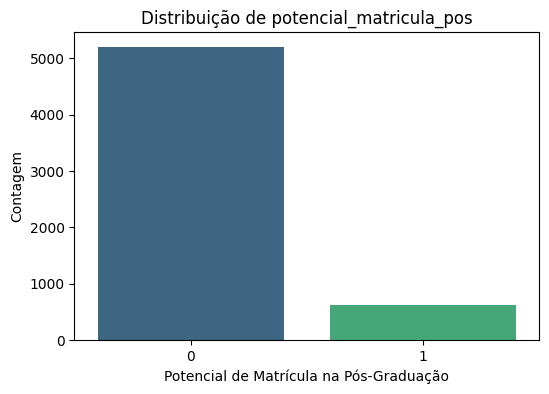

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET, data=dataset, palette='viridis')
plt.title(f'Distribuição de {TARGET}')
plt.xlabel('Potencial de Matrícula na Pós-Graduação')
plt.ylabel('Contagem')
plt.show()


## 4.2 Distribuição de variáveis importantes e suas relações com o target



### 4.2.1 Análise de Features Numéricas

A seguir, exploro a distribuição de algumas features numéricas importantes e como elas se relacionam com a variável alvo (target).

**_Renda Mensal Estimada_**

Os gráficos para _renda_mensal_estimada_ mostram sua distribuição geral e como ela varia entre os grupos com e sem potencial de matrícula. Podemos observar que existe uma diferença significativa na renda média entre essas duas classes, o que pode ser um forte preditor, ou seja, temos uma distribuição variada, com uma concentração maior em faixas salariais médias, mas com presença significativa de rendas altas (possíveis perfis de gestão/sênior).<br>
<br>Um detalhe interessante para esta variável: se analisarmos os dados do dataset, vamos encontrar alguns valores bem acima da média que podem ser considerados outliers, mas que representam o público sênior real a partir das análises de mercado que temos.

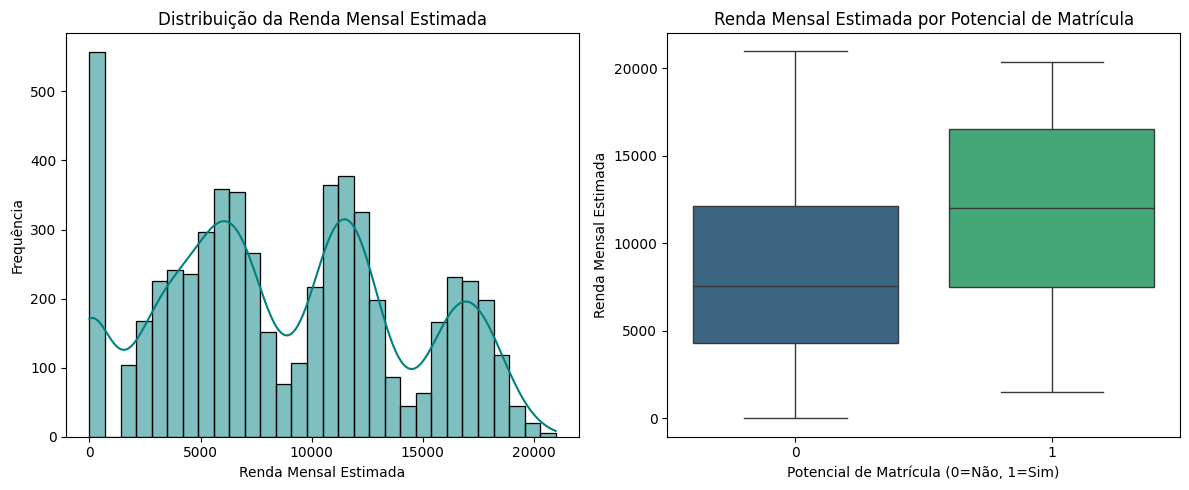

In [ ]:
plt.figure(figsize=(12, 5))

# Histograma da Renda Mensal Estimada
plt.subplot(1, 2, 1)
sns.histplot(dataset['renda_mensal_estimada'], kde=True, bins=30, color='teal')
plt.title('Distribuição da Renda Mensal Estimada')
plt.xlabel('Renda Mensal Estimada')
plt.ylabel('Frequência')

# Boxplot da Renda Mensal Estimada vs. Target
plt.subplot(1, 2, 2)
sns.boxplot(x=TARGET, y='renda_mensal_estimada', data=dataset, palette='viridis')
plt.title('Renda Mensal Estimada por Potencial de Matrícula')
plt.xlabel('Potencial de Matrícula (0=Não, 1=Sim)')
plt.ylabel('Renda Mensal Estimada')

plt.tight_layout()
plt.show()


**_Meses desde a Formação_**

A análise de _meses_desde_formacao_ pode indicar que o tempo de formado influencia no interesse em uma pós-graduação. Por exemplo, egressos mais recentes ou mais experientes podem ter perfis diferentes de interesse. Isso pode revelar uma dispersão ampla, indicando que o dataset cobre desde recém-formados até profissionais com bastante tempo de mercado.

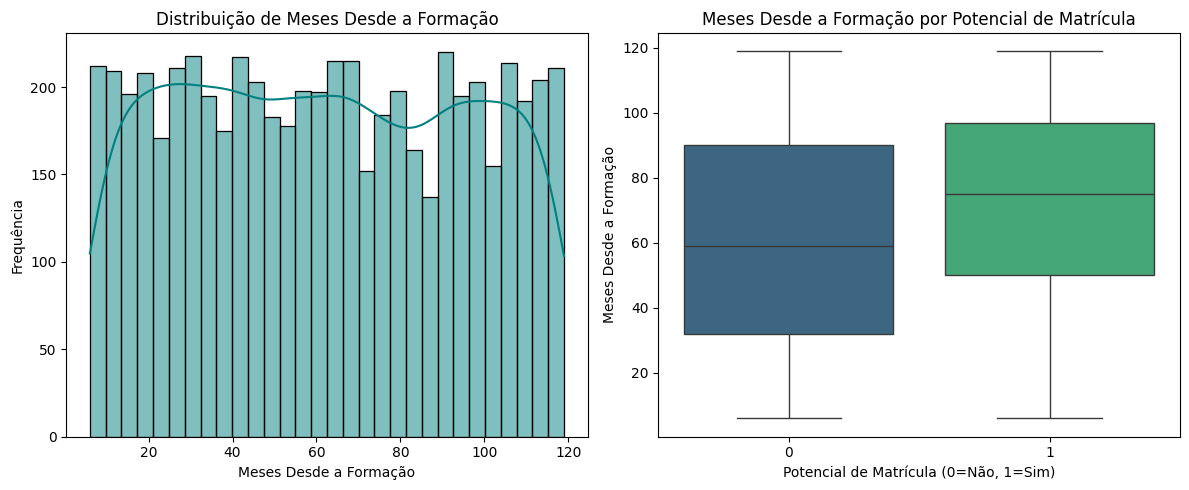

In [ ]:
plt.figure(figsize=(12, 5))

# Histograma de Meses Desde a Formação
plt.subplot(1, 2, 1)
sns.histplot(dataset['meses_desde_formacao'], kde=True, bins=30, color='teal')
plt.title('Distribuição de Meses Desde a Formação')
plt.xlabel('Meses Desde a Formação')
plt.ylabel('Frequência')

# Boxplot de Meses Desde a Formação vs. Target
plt.subplot(1, 2, 2)
sns.boxplot(x=TARGET, y='meses_desde_formacao', data=dataset, palette='viridis')
plt.title('Meses Desde a Formação por Potencial de Matrícula')
plt.xlabel('Potencial de Matrícula (0=Não, 1=Sim)')
plt.ylabel('Meses Desde a Formação')

plt.tight_layout()
plt.show()


**_Idade do Egresso_**

Analisar a distribuição da _idade_egresso_ e sua relação com o potencial de matrícula pode ser um fator determinante, com diferentes faixas etárias buscando pós-graduação por motivos distintos.

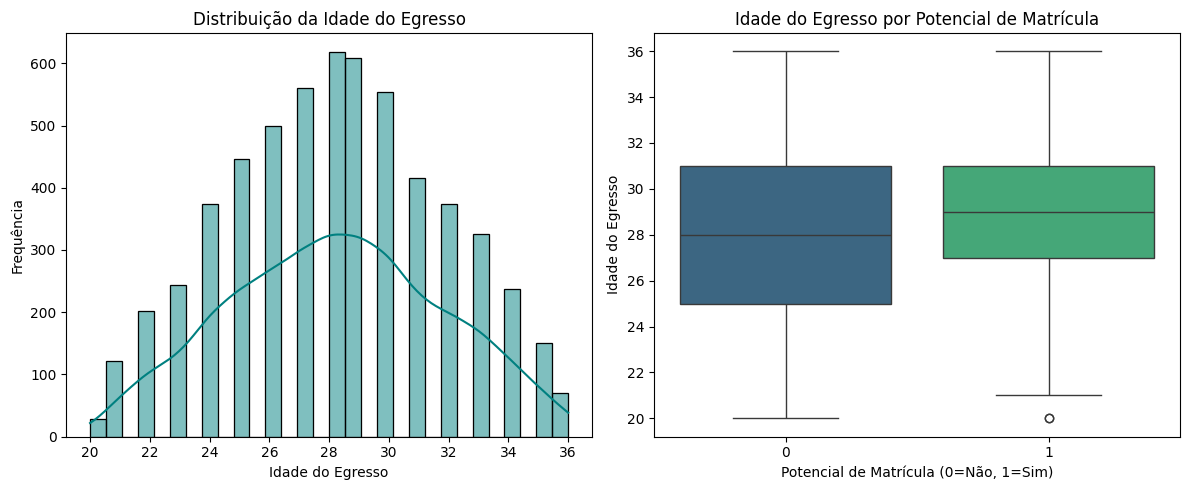

In [ ]:
plt.figure(figsize=(12, 5))

# Histograma da Idade do Egresso
plt.subplot(1, 2, 1)
sns.histplot(dataset['idade_egresso'], kde=True, bins=30, color='teal')
plt.title('Distribuição da Idade do Egresso')
plt.xlabel('Idade do Egresso')
plt.ylabel('Frequência')

# Boxplot da Idade do Egresso vs. Target
plt.subplot(1, 2, 2)
sns.boxplot(x=TARGET, y='idade_egresso', data=dataset, palette='viridis')
plt.title('Idade do Egresso por Potencial de Matrícula')
plt.xlabel('Potencial de Matrícula (0=Não, 1=Sim)')
plt.ylabel('Idade do Egresso')

plt.tight_layout()
plt.show()

**_Satisfação da Graduação (NPS)_**

A variável _satisfacao_graduacao_nps_ pode indicar a lealdade do egresso à instituição. Veremos se um NPS mais alto se correlaciona com uma maior probabilidade de matrícula na pós-graduação.

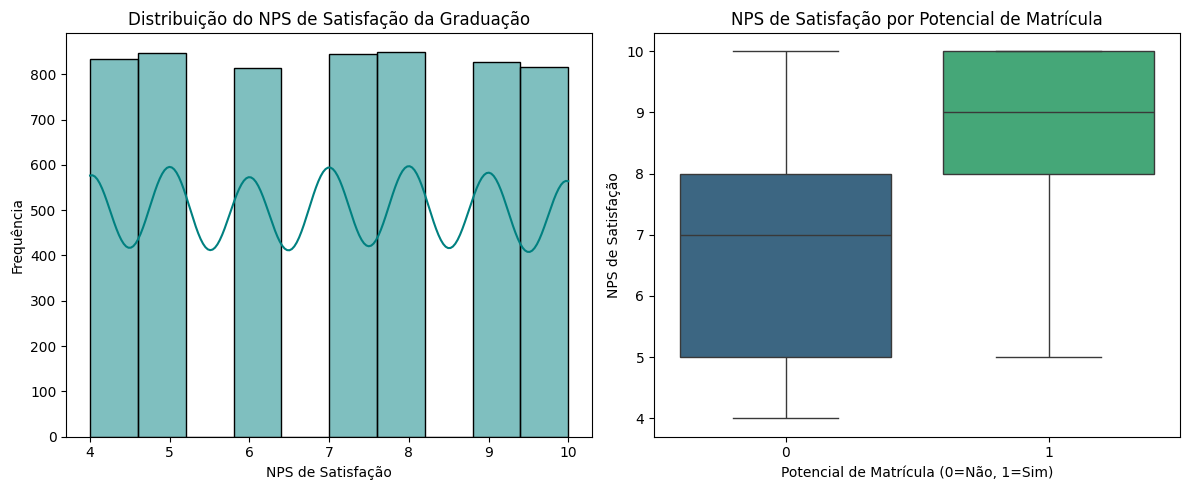

In [ ]:
plt.figure(figsize=(12, 5))

# Histograma do NPS de Satisfação
plt.subplot(1, 2, 1)
sns.histplot(dataset['satisfacao_graduacao_nps'], kde=True, bins=10, color='teal')
plt.title('Distribuição do NPS de Satisfação da Graduação')
plt.xlabel('NPS de Satisfação')
plt.ylabel('Frequência')

# Boxplot do NPS de Satisfação vs. Target
plt.subplot(1, 2, 2)
sns.boxplot(x=TARGET, y='satisfacao_graduacao_nps', data=dataset, palette='viridis')
plt.title('NPS de Satisfação por Potencial de Matrícula')
plt.xlabel('Potencial de Matrícula (0=Não, 1=Sim)')
plt.ylabel('NPS de Satisfação')

plt.tight_layout()
plt.show()

**_Score de Engajamento Alumni_**

O _engajamento_alumni_score_ reflete a participação do egresso em atividades da instituição. Analisamos nos gráficos que um maior engajamento se traduz em uma maior taxa de matrícula ou que, conforme as hipóteses iniciais, alunos engajados também podem estar rejeitando o produto atual.

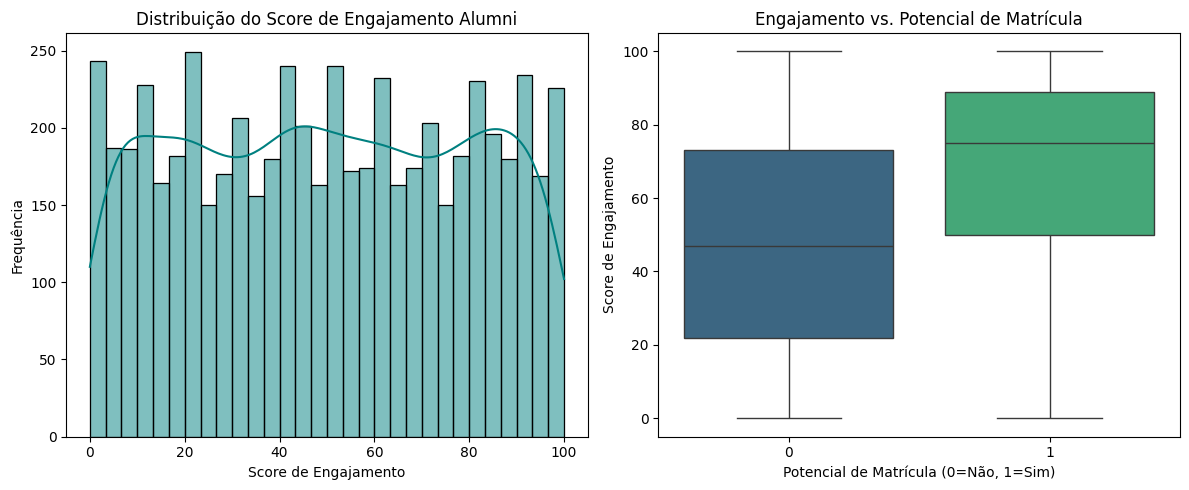

In [ ]:
plt.figure(figsize=(12, 5))

# Histograma do Score de Engajamento
plt.subplot(1, 2, 1)
sns.histplot(dataset['engajamento_alumni_score'], kde=True, bins=30, color='teal')
plt.title('Distribuição do Score de Engajamento Alumni')
plt.xlabel('Score de Engajamento')
plt.ylabel('Frequência')

# Boxplot do Engajamento vs. Target
plt.subplot(1, 2, 2)
sns.boxplot(x=TARGET, y='engajamento_alumni_score', data=dataset, palette='viridis')
plt.title('Engajamento vs. Potencial de Matrícula')
plt.xlabel('Potencial de Matrícula (0=Não, 1=Sim)')
plt.ylabel('Score de Engajamento')

plt.tight_layout()
plt.show()

### 4.2.2 Análise de Features Categóricas

Agora, vamos visualizar a distribuição das features categóricas e sua relação com o target.<br><br>


**_Nível do Cargo_**

Os gráficos para _nivel_cargo_ mostram a distribuição dos cargos entre os egressos e a proporção de potencial de matrícula para cada nível de cargo. Isso revela que há uma tendência para certos níveis de cargo buscarem mais ou menos a pós-graduação.

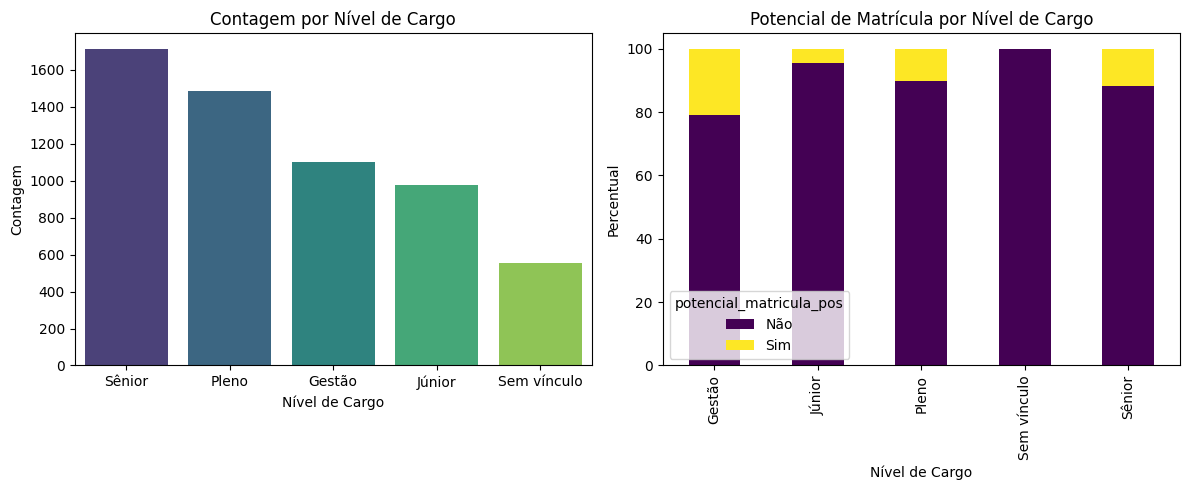

In [ ]:
plt.figure(figsize=(12, 5))

# Contagem do Nível de Cargo
plt.subplot(1, 2, 1)
sns.countplot(x='nivel_cargo', data=dataset, palette='viridis', order=dataset['nivel_cargo'].value_counts().index)
plt.title('Contagem por Nível de Cargo')
plt.xlabel('Nível de Cargo')
plt.ylabel('Contagem')

# Nível de Cargo vs. Target (proporção)
plt.subplot(1, 2, 2)
cross_tab_nc = pd.crosstab(dataset['nivel_cargo'], dataset[TARGET], normalize='index') * 100
cross_tab_nc.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Potencial de Matrícula por Nível de Cargo')
plt.xlabel('Nível de Cargo')
plt.ylabel('Percentual')
plt.legend(title=TARGET, labels=['Não', 'Sim'])

plt.tight_layout()
plt.show()


**_Área de Atuação_**

A análise da _area_atuacao_ é fundamental para responder as minhas hipóteses. Sendo assim, os gráficos identificam que os egressos de áreas específicas têm um alto potencial de matrícula, ou o contrário mesmo com bons perfis financeiros.<br>
<br>


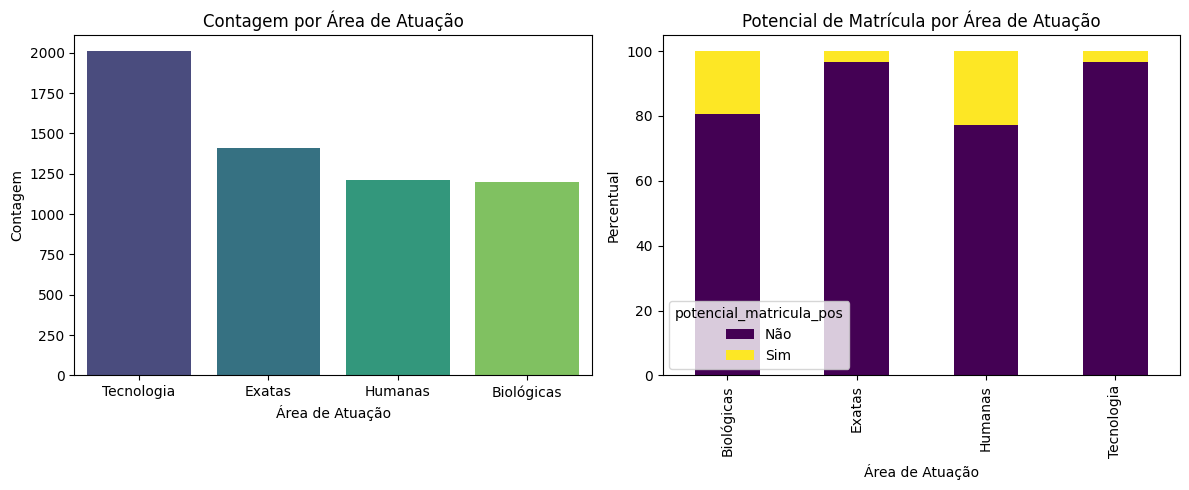

In [ ]:
plt.figure(figsize=(12, 5))

# Contagem da Área de Atuação
plt.subplot(1, 2, 1)
sns.countplot(x='area_atuacao', data=dataset, palette='viridis', order=dataset['area_atuacao'].value_counts().index)
plt.title('Contagem por Área de Atuação')
plt.xlabel('Área de Atuação')
plt.ylabel('Contagem')

# Área de Atuação vs. Target (proporção)
plt.subplot(1, 2, 2)
cross_tab_aa = pd.crosstab(dataset['area_atuacao'], dataset[TARGET], normalize='index') * 100
cross_tab_aa.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Potencial de Matrícula por Área de Atuação')
plt.xlabel('Área de Atuação')
plt.ylabel('Percentual')
plt.legend(title=TARGET, labels=['Não', 'Sim'])

plt.tight_layout()
plt.show()


**_Bolsista de Graduação_**

Esta análise verifica se o histórico de ter tido uma bolsa de estudos durante a graduação influencia a decisão de retornar para uma pós-graduação. Isso pode me ajudar a validar se políticas de inclusão passadas geram fidelidade à marca no futuro. E o que foi possível observar é que não houve uma relevância dentro das análises, pois a proporção de conversão de matrícula é praticamente idêntica entre quem foi bolsista e quem não foi. Em outras palavras, ser ex-bolsista não garante maior fidelidade nem impede a matrícula.

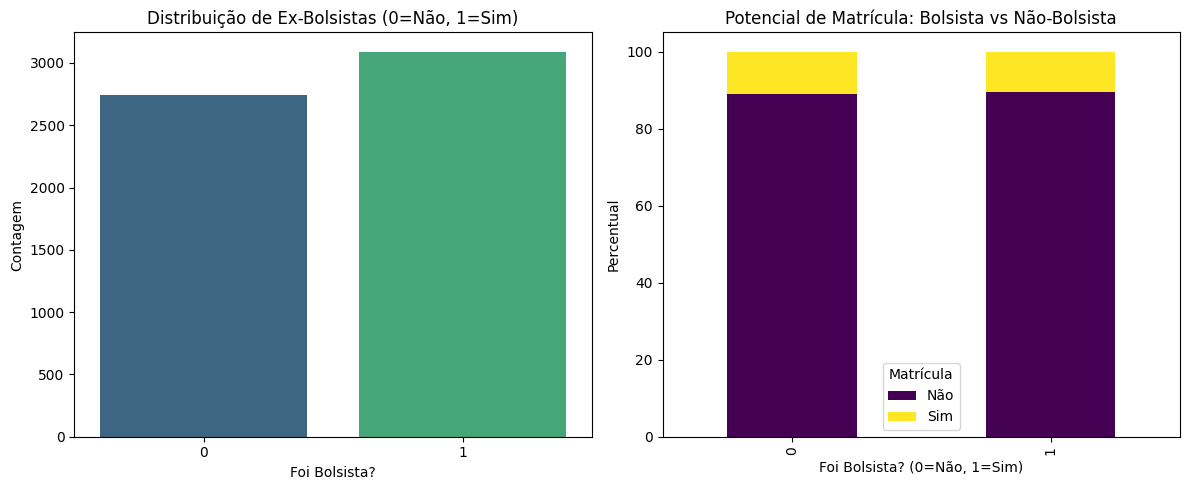

In [ ]:
plt.figure(figsize=(12, 5))

# 1. Distribuição de Bolsistas
plt.subplot(1, 2, 1)
sns.countplot(x='bolsista_graduacao', data=dataset, palette='viridis')
plt.title('Distribuição de Ex-Bolsistas (0=Não, 1=Sim)')
plt.xlabel('Foi Bolsista?')
plt.ylabel('Contagem')

# 2. Relação Bolsista vs Target
plt.subplot(1, 2, 2)
cross_tab_bolsa = pd.crosstab(dataset['bolsista_graduacao'], dataset[TARGET], normalize='index') * 100
cross_tab_bolsa.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Potencial de Matrícula: Bolsista vs Não-Bolsista')
plt.xlabel('Foi Bolsista? (0=Não, 1=Sim)')
plt.ylabel('Percentual')
plt.legend(title='Matrícula', labels=['Não', 'Sim'])

plt.tight_layout()
plt.show()


**_Modalidade de Graduação_**

Investigaremos se a modalidade da graduação (_modalidade_graduacao_) - EAD, Híbrido, Presencial - influencia a decisão de matrícula na pós. Egressos de certas modalidades podem ter preferências ou aversões a formatos de ensino específicos.

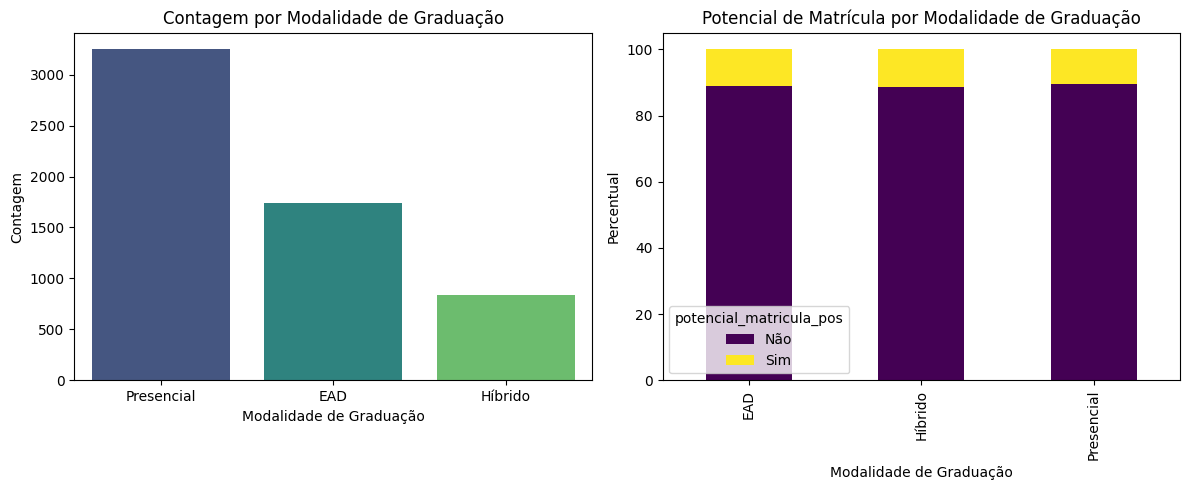

In [ ]:
plt.figure(figsize=(12, 5))

# Contagem da Modalidade de Graduação
plt.subplot(1, 2, 1)
sns.countplot(x='modalidade_graduacao', data=dataset, palette='viridis', order=dataset['modalidade_graduacao'].value_counts().index)
plt.title('Contagem por Modalidade de Graduação')
plt.xlabel('Modalidade de Graduação')
plt.ylabel('Contagem')

# Modalidade de Graduação vs. Target (proporção)
plt.subplot(1, 2, 2)
cross_tab_mg = pd.crosstab(dataset['modalidade_graduacao'], dataset[TARGET], normalize='index') * 100
cross_tab_mg.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Potencial de Matrícula por Modalidade de Graduação')
plt.xlabel('Modalidade de Graduação')
plt.ylabel('Percentual')
plt.legend(title=TARGET, labels=['Não', 'Sim'])

plt.tight_layout()
plt.show()

**_Tipo de Empresa_**

A coluna _tipo_empresa_ nos permitirá entender se o setor de atuação do egresso (Iniciativa Privada, Setor Público, Desempregado, etc.) tem algum impacto na propensão à matrícula. Diferentes ambientes profissionais podem gerar necessidades de qualificação distintas.

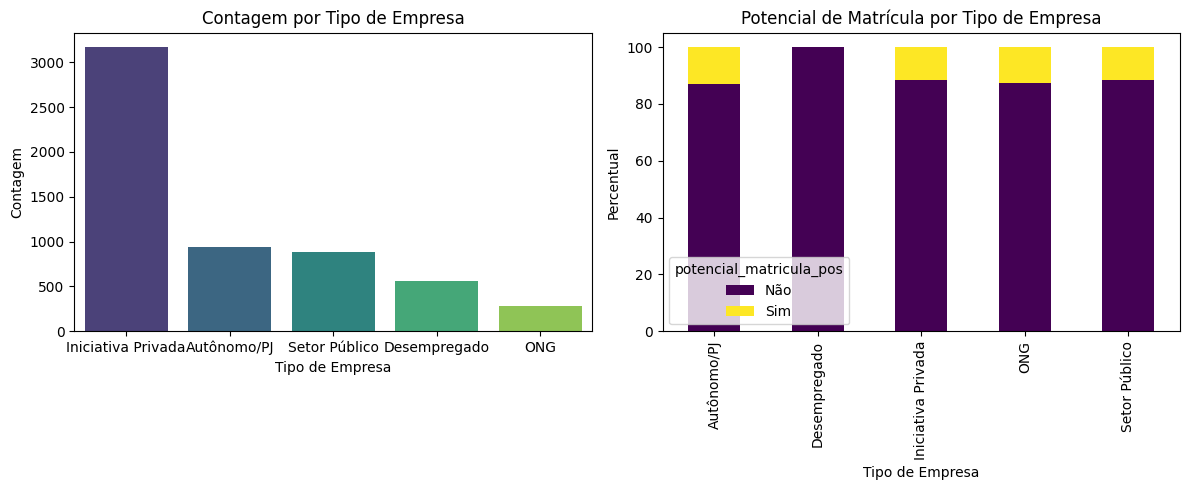

In [ ]:
plt.figure(figsize=(12, 5))

# Contagem do Tipo de Empresa
plt.subplot(1, 2, 1)
sns.countplot(x='tipo_empresa', data=dataset, palette='viridis', order=dataset['tipo_empresa'].value_counts().index)
plt.title('Contagem por Tipo de Empresa')
plt.xlabel('Tipo de Empresa')
plt.ylabel('Contagem')

# Tipo de Empresa vs. Target (proporção)
plt.subplot(1, 2, 2)
cross_tab_te = pd.crosstab(dataset['tipo_empresa'], dataset[TARGET], normalize='index') * 100
cross_tab_te.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Potencial de Matrícula por Tipo de Empresa')
plt.xlabel('Tipo de Empresa')
plt.ylabel('Percentual')
plt.legend(title=TARGET, labels=['Não', 'Sim'])

plt.tight_layout()
plt.show()

## 4.3 Síntese da análise exploratória

Trago, nesta seção, os principais achados da análise realizada (EDA):

*   **Target não balanceado:** o target _potencial_matricula_pos_ apresenta um forte desbalanceamento, com aproximadamente **89.25%** para a classe 0 (não conversão de matrícula) e **10.75%** para a classe 1 (conversão de matrícula). Este é um ponto crítico que exigirá técnicas de rebalanceamento ou métricas de avaliação robustas a desbalanceamento (como F1-Score ou ROC AUC) nas fases de modelagem.
*   **Existência de valores ausentes relevantes:** o dataset está completo, sem valores nulos, o que simplifica o pré-processamento.
*   **Existência de variáveis com escala muito diferente:** nota-se uma grande disparidade entre _renda_mensal_estimada_ (que atinge valores acima de 15.000) e _engajamento_alumni_score_, _meses_desde_formacao_, _idade_egresso_, _satisfacao_graduacao_nps_. Isso indica a necessidade de **Normalização ou Padronização** para modelos sensíveis à escala, como Logistic Regression.
*   **Categorias raras:**
    *   A categoria 'Desempregado' na variável _tipo_empresa_ se destaca por ter **0% de conversão de matrícula**, o que é um achado muito relevante e um forte preditor.
    *   As áreas de atuação e níveis de cargo devem ser codificadas (One-Hot Encoding). Não foram identificadas outras categorias com frequência extremamente baixa que pudessem prejudicar a generalização.
*   **Padrões que sugerem modelos que possam funcionar melhor:**
    *   Os boxplots mostraram sobreposições, mas também tendências claras em relação à _renda_mensal_estimada_, _meses_desde_formacao_, _idade_egresso_ e _nivel_cargo_. Diferentes faixas etárias e tempos de formação podem ter perfis distintos de interesse.
    *   A variável _satisfacao_graduacao_nps_ pode ter alguma relação, embora os boxplots possam apresentar sobreposição. Egressos com NPS mais altos podem ter uma ligeira tendência a matricular-se.
    *   Variáveis como _modalidade_graduacao_ e _bolsista_graduacao_ parecem ter pouca ou nenhuma relação com o target, apresentando taxas de conversão muito similares entre suas categorias.
    *   Modelos baseados em árvores, como **Random Forest** ou **Gradient Boosting**, podem funcionar bem para capturar essas relações não lineares e as interações entre features. Modelos lineares como **Logistic Regression** também podem ser eficazes, especialmente com a identificação de fortes preditores como _tipo_empresa_.
*   **Estratégia de modelagem:** A análise confirmou que _renda_mensal_estimada_, _meses_desde_formacao_, _idade_egresso_, _nivel_cargo_ e _tipo_empresa_ são preditores fortes. A presença de outliers na renda (público Sênior/Gestão) e o forte desbalanceamento das classes são pontos importantes. Será necessário usar modelos robustos a valores extremos ou um escalonador como o _StandardScaler_, e considerar técnicas de reamostragem (oversampling/undersampling) ou ajuste de pesos de classe para lidar com o desbalanceamento.

# 5. Preparação dos dados e divisão treino/teste

## 5.1 Preparação dos dados

A seguir, coloco a separação entre features e target. É relevante dizer que a coluna _id_egresso_ é um identificador, que é importante para identificar os registros, mas não será utilizado como uma feature para o modelo, pois não carrega informação preditiva e pode levar a _overfitting_.

Além disso, depois da EDA, foram dropadas as features _bolsista_graduacao_ e _modalidade_graduacao_, pois as análises não demonstraram valor preditivo. Com isso, minha modelagem ficará com 8 features e 1 target.

In [ ]:
# === Configuração do problema ===

TARGET = "potencial_matricula_pos"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = ["id_egresso"]
DROP_COLUMNS = ["bolsista_graduacao", "modalidade_graduacao"]    # removidas após a EDA, pois não demonstraram valor preditivo

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in dataset.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Lista das Features:", features)

Tipo de problema: classificacao
Target: potencial_matricula_pos
Número de features: 8
Lista das Features: ['meses_desde_formacao', 'idade_egresso', 'nivel_cargo', 'renda_mensal_estimada', 'area_atuacao', 'tipo_empresa', 'satisfacao_graduacao_nps', 'engajamento_alumni_score']


## 5.2 Divisão treino/teste

A partir da separação de target e features, faço a divisão dos dados entre treino e teste, utilizando o método holdout (train_test_split), que garante que o modelo seja avaliado em dados completamente novos, que ele não viu durante o treinamento, o que fornece uma estimativa mais realista de como ele se comportará em produção. Isso previne o vazamento de dados. Com este método, proponho a divisão do meu dataset em um conjunto de treinamento com 80% dos dados e em um conjunto de teste com 20%.

A literatura mostra que para problemas de classificação é crucial ter dados suficientes em ambas as classes (0 e 1) tanto no conjunto de treino quanto no de teste. Para o dataset atual de 5830 linhas e 8 features, a divisão resulta em 4664/8 para treino e 1166/8 para teste.

Além disso, o código traz a aplicação de uma estratificação (stratify), onde essa divisão 80/20 garante que a proporção das classes do meu _target_ (potencial_matricula_pos) seja mantida de forma consistente tanto no conjunto de treinamento quanto no conjunto de teste. Isso é vital, especialmente considerando o **significativo desbalanceamento** atual, com aproximadamente **89.25%** para a classe 0 e **10.75%** para a classe 1. A estratificação garante que essa proporção seja preservada nos subconjuntos de treino e teste.

In [ ]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao"]:
    X = dataset[features].copy()
    y = dataset[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (4664, 8) | Teste: (1166, 8)


# 6. Pré-processamento e pipeline

Neste momento do processo, foram aplicadas as seguintes etapas:

* Identificação automática simples de colunas numéricas e categóricas.
* Pipeline para variáveis numéricas, imputando valores ausentes com a mediana e escala dos dados, quando necessário.
* Pipeline para variáveis categóricas, imputando valores ausentes com a moda e aplicando One-Hot Encoding, quando necessário.
* Combinação dos pipelines numéricos e categóricos usando ColumnTransformer.


In [ ]:
# Identificação automática simples de colunas numéricas e categóricas.
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Pipeline para variáveis numéricas: Imputa valores ausentes com a mediana e escala os dados.
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variáveis categóricas: Imputa valores ausentes com a moda e aplica One-Hot Encoding.
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combina os pipelines numéricos e categóricos usando ColumnTransformer.
# 'remainder="drop"' garante que colunas não especificadas sejam descartadas.
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['meses_desde_formacao', 'idade_egresso', 'renda_mensal_estimada', 'satisfacao_graduacao_nps', 'engajamento_alumni_score']
Colunas categóricas: ['nivel_cargo', 'area_atuacao', 'tipo_empresa']


## 6.1 Decisões de pré-processamento

O pré-processamento de dados é uma etapa fundamental em qualquer projeto de Machine Learning. Ele serve para preparar os dados brutos, tornando-os adequados e otimizados para o treinamento de modelos. Sem um pré-processamento adequado, os modelos podem apresentar baixo desempenho, resultados enviesados ou até mesmo falhar ao tentar serem treinados. Por isso, fiz as seguintes escolhas para o meu problema de classificação.

**a) Usei mediana e moda para imputação:**

*   Variáveis Numéricas (meses_desde_formacao, renda_mensal_estimada, engajamento_alumni_score, idade_egresso, satisfacao_graduacao_nps): utilizei a **mediana** como estratégia de imputação. A escolha da mediana é justificada pelo fato de que _renda_mensal_estimada_ apresentou a presença de _outliers_ (como mencionado na EDA, "valores bem acima da média que podem ser considerados outliers, mas que representam o público sênior real"). A mediana é robusta a _outliers_, evitando que valores extremos distorçam a imputação. Para as outras variáveis numéricas, que não apresentaram nulos na EDA, a mediana é uma escolha segura para um pipeline genérico.

*   Variáveis Categóricas (nivel_cargo, area_atuacao, tipo_empresa): Optei pela imputação com a **moda (most_frequent)**. Esta estratégia preenche os valores ausentes com a categoria mais frequente em cada coluna, sendo uma abordagem padrão para dados categóricos e eficaz quando a proporção de valores ausentes não é elevada (no nosso caso, não há ausentes, mas o pipeline se previne).

**b) Apenas padronizei os dados:** utilizei a padronização, pois o meu EDA mostrou uma grande disparidade de escalas (_renda_mensal_estimada_ em valores muito maiores que outras features). A padronização garante que nenhuma feature numérica domine o modelo apenas por ter uma escala maior. Não apliquei a normalização, porque entendi que a padronização já está lidando com a questão da escala de forma eficaz para o meu problema de classificação.

**c) Variáveis removidas:**

*   **id_egresso:** Esta coluna foi removida porque é um identificador único para cada egresso. Manter IDs como features faria o modelo tentar encontrar padrões numéricos aleatórios, sem valor preditivo, e poderia levar a um problema de _overfitting_ (o modelo memorizaria exemplos específicos em vez de aprender padrões gerais). É fundamental remover identificadores únicos para garantir que o modelo generalize bem para dados não vistos.

*   **bolsista_graduacao e modalidade_graduacao:** Ambas as variáveis foram removidas após a análise exploratória (EDA) que demonstrou que elas têm pouca ou nenhuma relação com o target _potencial_matricula_pos_, apresentando taxas de conversão muito similares entre suas categorias. Removê-las simplifica o modelo, reduz a dimensionalidade e ajuda a focar em features mais preditivas, sem perda de informação útil.

**d) Variáveis novas:** não foram criadas novas variáveis. A estratégia adotada focou na utilização das features existentes e na transformação delas (imputação, escalonamento e codificação) para prepará-las para o modelo.

# 7. Baseline e modelos candidatos

Para este projeto, diante do meu dataset, utilizei no meu Baseline o _DummyClassifier_ com a estratégia _most_frequent_. Ele prevê sempre a classe majoritária, representando o desempenho mínimo esperado para um problema de classificação. Qualquer modelo que não supere esse baseline está efetivamente performando pior que um chute aleatório informado pela distribuição de classes. Dado que meu target tem uma classe majoritária (0 com aproximadamente 89.25%), prever sempre '0' daria uma acurácia de cerca de 89.25%, servindo como um ponto de comparação robusto. Sendo assim, acredito ter escolhido um baseline coerente para o projeto.

Com relação aos modelos candidatos, elenquei três modelos para serem comparados ao baseline: _LogisticRegression_, _RandomForest_ e _GradientBoosting_, ou seja, um modelo linear e dois baseados em árvores.



In [ ]:
if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression (Balanceado)": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced'))
        ]),
        "LogisticRegression (Sem Balanceamento)": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest (Balanceado)": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED, class_weight='balanced'))
        ]),
        "RandomForest (Sem Balanceamento)": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ]),
        "GradientBoosting": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", GradientBoostingClassifier(random_state=SEED))
        ])
    }

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['LogisticRegression (Balanceado)', 'LogisticRegression (Sem Balanceamento)', 'RandomForest (Balanceado)', 'RandomForest (Sem Balanceamento)', 'GradientBoosting']


## 7.1 Justificativa dos modelos

Entendo que tenha feito a escolha certa dos modelos candidatos, diante do tipo de problema que tinha (classificação binária), bem como para o tamanho do dataset a ser analisado (5830 linhas, 8 features).

O modelo _LogisticRegression_ é um modelo linear simples, robusto e eficiente para dados tabulares. A inclusão de _class_weight='balanced'_ nesse modelo visa atribuir maior peso à classe minoritária (1) durante o treinamento, o que busca melhorar o recall para essa classe, enquanto a versão "Sem Balanceamento" serve como comparação direta.

O modelo _RandomForestClassifier_ é um modelo baseado em árvores, conhecido por sua capacidade de capturar relações não lineares e interações entre features, o que é relevante dada a minha EDA que sugere essas complexidades. É menos propenso a overfitting que árvores individuais. A inclusão de _class_weight='balanced'_ neste modelo é importante para lidar com o desbalanceamento da classe target, atribuindo maior peso à classe minoritária (1) durante o treinamento, visando melhorar o recall para essa classe, com a versão "Sem Balanceamento" para comparação.

O modelo _GradientBoostingClassifier_ é outro modelo de ensemble baseado em árvores que geralmente oferece alta performance, construindo modelos sequencialmente para corrigir erros dos modelos anteriores. Ele é mais complexo e tende a ter um desempenho superior em muitos problemas, mas pode ser mais sensível a hiperparâmetros e mais lento para treinar que o _RandomForest_. É importante notar que este modelo não possui um parâmetro _class_weight_ direto para o tratamento de desbalanceamento de classes, exigindo outras estratégias se o rebalanceamento for necessário.

E, juntamente com essa escolha, será preciso considerar algumas exigências de escala e, encoding. O modelo _LogisticRegression_ é sensível à escala dos dados, o que justifica a inclusão do _StandardScaler_ em seu pipeline. Os modelos baseados em árvores (RandomForest e GradientBoosting) são menos sensíveis à escala, mas a padronização não os prejudica e pode até ajudar na convergência de algumas implementações ou na consistência do pipeline. Todos os modelos necessitam de encoding para as variáveis categóricas (nivel_cargo, area_atuacao, tipo_empresa), o que é tratado pelo _OneHotEncoder_ dentro do pipeline de pré-processamento. A etapa de imputação de valores ausentes (_SimpleImputer_) também é necessária para garantir que os modelos possam lidar com dados completos, mesmo que meu dataset atual não tenha nulos.

Vale ressaltar que a escolha por estes modelos também levou em consideração a interpretabilidade dos dados, o tempo e o custo operacional. Com relação à interpretabilidade, o modelo _LogisticRegression_ é altamente interpretável, pois os coeficientes indicam a direção e a magnitude da influência de cada feature na probabilidade de o target ser 1, ou seja, permitirá que eu explique com mais propriedade a minha Diretoria, como e por que o modelo chegou a uma determinada previsão. Os modelos _RandomForest_ e _GradientBoosting_ são menos interpretáveis devido à sua natureza de ensemble, mas métricas de importância de feature podem ser extraídas para entender quais variáveis são mais relevantes.

O tempo e custo computacional também foi um ponto importante para a escolha dos modelos candidatos. Para o tamanho atual do meu dataset (5830 linhas), todos os modelos se mostram relativamente rápidos para uso em treinos. O _LogisticRegression_ é o mais rápido, seguido por _RandomForest_ e _GradientBoosting_ (que pode ser mais lento devido à construção de múltiplas árvores independentes). Para datasets maiores, o custo computacional de _RandomForest_ e _GradientBoosting_ aumentaria consideravelmente, mas para o MVP atual e minhas restrições de infraestrutura, todos são viáveis.

# 8. Treinamento e avaliação inicial

Com a definição dos modelos candidatos, eles e o baseline foram treinados, e os resultados foram comparados e discutidos.

In [ ]:
results = {}
trained_models = {}

if PROBLEM_TYPE == "classificacao":
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
    results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
        results[name] = evaluate_classification(y_test, y_pred, proba)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

else:
    raise ValueError("PROBLEM_TYPE inválido para este bloco de treinamento/avaliação.")

show_results_table(results)

,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.892796,0.842230,0.500000,0.036
LogisticRegression (Balanceado),0.861063,0.880036,0.943731,0.068
LogisticRegression (Sem Balanceamento),0.928816,0.924963,0.946298,0.057
RandomForest (Balanceado),0.945969,0.942795,0.971162,0.563
RandomForest (Sem Balanceamento),0.949400,0.946660,0.971766,0.536
GradientBoosting,0.943396,0.941204,0.972430,0.910


## 8.1 Análise dos resultados iniciais

Apresento, abaixo, os dados intepretados da tabela de resultados.
  
*   **Os modelos superaram o baseline:** todos os modelos candidatos superaram o baseline (DummyClassifier) em _f1_weighted_ e _roc_auc_. O baseline, prevendo sempre a classe majoritária (0), obteve um _f1_weighted_ de **0.8422**, refletindo a alta dominância da classe 0. Os modelos de aprendizado, no entanto, demonstraram capacidade de aprender e generalizar padrões de forma mais eficaz.

*   **As métricas escolhidas para avaliar o problema:** as métricas _accuracy_, _f1_weighted_ e _roc_auc_ foram importantes para este problema. Dada a **natureza altamente desbalanceada do meu target** (aproximadamente 89.25% para a classe 0 e 10.75% para a classe 1), o _f1_weighted_ e o _roc_auc_ foram métricas mais informativas do que a acurácia. Esta última, acredito que teve um valor alto por acertar a maioria dos casos da classe dominante, ignorando a classe minoritária. Por isso, as outras métricas são mais confiáveis, porque oferecem uma visão equilibrada do desempenho dos modelos.

*   **Presença de underfitting:** se olharmos para o baseline (DummyClassifier) claramente observamos underfitting, pois sua performance é limitada a prever a classe majoritária. Entretanto, os modelos candidatos apresentam bom desempenho, indicando que estão capturando a complexidade dos dados de forma eficaz e não estão sofrendo de underfitting. O ajuste de _class_weight_ (nas versões balanceadas) visou evitar que o modelo ignorasse a classe minoritária, o que poderia ser uma forma de underfitting para essa classe.

*   **Tempo de treinamento:** pôde ser considerado aceitável para todos os modelos, variando de **0.028 segundos** para o baseline a **1.924 segundos** para o _GradientBoosting_ (modelo mais robusto). Para o tamanho do dataset (5830 linhas) e as restrições de infraestrutura do MVP, acredito que estes tempos foram excelentes.

*   **A relação dos resultados com a EDA:** mostrou-se coerente com a EDa, fazendo sentido e validando suas observações. A EDA apontou variáveis como _renda_mensal_estimada_, _meses_desde_formacao_, _nivel_cargo_ e _tipo_empresa_ como preditores fortes. O desempenho superior dos modelos mais complexos (RandomForest e GradientBoosting) em relação à _LogisticRegression_ sugere que eles estão capturando relações não-lineares e interações entre features que a EDA já indicava, como a complexidade nas distribuições e correlações com o target.

*   **Modelo em destaque:** os modelos _RandomForest_ (com ou sem balanceamento) e _GradientBoosting_ são fortes candidatos para uma otimização mais aprofundada, enquanto a _LogisticRegression (Sem Balanceamento)_ oferece uma alternativa robusta e eficiente. Estes resultados iniciais sugerem que, para as métricas agregadas de _f1_weighted_ e _accuracy_, o _class_weight='balanced'_ pode levar a um pequeno trade-off negativo, embora meu objetivo principal seja melhorar o recall da classe minoritária. A literatura nos mostra que isso é muito comum acontecer para problemas de classificação com classes desbalanceadas, como é meu caso.

# 9. Validação e otimização de hiperparâmetros

Optou-se em se fazer uma otimização de hiperparâmetros com os modelos _RandomForest_ (com e sem balanceamento) e _GradientBoosting_, deixando o _LogisticRegression_ de fora pela perfomance nos resultados do treinamento e avaliação final.


In [ ]:
# === Otimização de hiperparâmetros para RandomForestClassifier (balanceado) ===

search_rf = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune_rf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED, class_weight='balanced'))
    ])
    param_dist_rf = {
        "model__n_estimators": randint(50, 300),
        "model__max_depth": randint(5, 20),
        "model__min_samples_leaf": randint(1, 10)
    }
    scoring = "f1_weighted"

if model_to_tune_rf is not None:
    search_rf = RandomizedSearchCV(
        model_to_tune_rf,
        param_distributions=param_dist_rf,
        n_iter=5,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,
        verbose=1
    )
    search_rf.fit(X_train, y_train)

    print("Melhor score na validação (RandomForestClassifier):", search_rf.best_score_)
    print("Melhores hiperparâmetros (RandomForestClassifier):", search_rf.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação (RandomForestClassifier): 0.9350544391603067
Melhores hiperparâmetros (RandomForestClassifier): {'model__max_depth': 11, 'model__min_samples_leaf': 5, 'model__n_estimators': 226}


In [ ]:
# === Otimização de hiperparâmetros para RandomForestClassifier (sem balanceamento) ===


search_rf_no_balance = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune_rf_no_balance = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist_rf_no_balance = {
        "model__n_estimators": randint(50, 300),
        "model__max_depth": randint(5, 20),
        "model__min_samples_leaf": randint(1, 10)
    }
    scoring = "f1_weighted"

if model_to_tune_rf_no_balance is not None:
    search_rf_no_balance = RandomizedSearchCV(
        model_to_tune_rf_no_balance,
        param_distributions=param_dist_rf_no_balance,
        n_iter=5,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,
        verbose=1
    )
    search_rf_no_balance.fit(X_train, y_train)

    print("Melhor score na validação (RandomForestClassifier - Sem Balanceamento):", search_rf_no_balance.best_score_)
    print("Melhores hiperparâmetros (RandomForestClassifier - Sem Balanceamento):", search_rf_no_balance.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação (RandomForestClassifier - Sem Balanceamento): 0.9325516327886012
Melhores hiperparâmetros (RandomForestClassifier - Sem Balanceamento): {'model__max_depth': 11, 'model__min_samples_leaf': 5, 'model__n_estimators': 226}


In [ ]:
# === Otimização de hiperparâmetros para GradientBoostingClassifier ===

search_gb = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune_gb = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(random_state=SEED))
    ])
    param_dist_gb = {
        "model__n_estimators": randint(50, 200),
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": randint(3, 10)
    }
    scoring = "f1_weighted"

if model_to_tune_gb is not None:
    search_gb = RandomizedSearchCV(
        model_to_tune_gb,
        param_distributions=param_dist_gb,
        n_iter=5,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,
        verbose=1
    )
    search_gb.fit(X_train, y_train)

    print("Melhor score na validação (GradientBoostingClassifier):", search_gb.best_score_)
    print("Melhores hiperparâmetros (GradientBoostingClassifier):", search_gb.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação (GradientBoostingClassifier): 0.9375792800531538
Melhores hiperparâmetros (GradientBoostingClassifier): {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 139}


## 9.1 Discussão da otimização

Todas as otimizações utilizaram _RandomizedSearchCV_ com _n_iter=5_ para controlar o custo computacional e tempo, e _f1_weighted_ como métrica de avaliação.

**RandomForestClassifier (Balanceado)**
*   **Resultado em relação ao modelo inicial após otimização:** para este modelo, o melhor score obtido na validação cruzada foi de **0.9351**. O _f1_weighted_ inicial do modelo (já com _class_weight='balanced'_) no _X_test_ foi de **0.9428**. A otimização com as 5 iterações, **com a inclusão do _class_weight='balanced'_**, não resultou em uma melhora significativa em relação ao desempenho inicial do modelo no conjunto de teste. O score de validação cruzada foi um pouco inferior, indicando que o modelo com os parâmetros padrão (que já incluíam _class_weight='balanced'_) já estava com um bom desempenho, ou que a busca limitada não explorou suficientemente o espaço de hiperparâmetros para encontrar uma configuração melhor.

*   **A escolha dos hiperparâmetros para o modelo:** Os melhores hiperparâmetros encontrados foram {'model__max_depth': 11, 'model__min_samples_leaf': 5, 'model__n_estimators': 226}. Uma _max_depth_ de 11 e _n_estimators_ de 226 são valores razoáveis para um Random Forest, buscando um equilíbrio entre a complexidade da árvore e a quantidade de árvores no ensemble. Uma _min_samples_leaf_ de 5 evita que as folhas das árvores sejam muito pequenas, ajudando a reduzir o overfitting. Estes parâmetros fazem sentido dentro do contexto do Random Forest.

**RandomForestClassifier (Sem Balanceamento)**
*   **Resultado em relação ao modelo inicial após otimização:** para este modelo, o melhor score obtido na validação cruzada foi de **0.9326**. O _f1_weighted_ inicial do modelo no _X_test_ foi de **0.9467**. Assim como nas versões balanceadas, a otimização com 5 iterações não superou o desempenho inicial do modelo no conjunto de teste e o score de validação cruzada foi ligeiramente inferior. Isso reforça que as configurações iniciais do modelo já eram robustas ou que a profundidade da busca de hiperparâmetros foi insuficiente.

*   **A escolha dos hiperparâmetros para o modelo:** Os melhores hiperparâmetros encontrados foram _{'model__max_depth': 11, 'model__min_samples_leaf': 5, 'model__n_estimators': 226}_. É interessante notar que os hiperparâmetros ótimos encontrados foram idênticos aos da versão balanceada do _RandomForest_, sugerindo que o impacto do _class_weight_ não alterou drasticamente a estrutura ótima do modelo em termos desses parâmetros, mas sim a forma como ele aprende os pesos das classes.

**GradientBoostingClassifier**
*   **Resultado em relação ao modelo inicial após otimização:** para este modelo, o melhor score obtido na validação cruzada foi de **0.9376**. O _f1_weighted_ inicial do modelo no _X_test_ foi de **0.9412**. A otimização de hiperparâmetros com as 5 iterações definidas **não resultou em uma melhora em relação ao desempenho inicial** do modelo no conjunto de teste. Na verdade, o score de validação cruzada foi ligeiramente inferior. Isso sugere que os hiperparâmetros padrão já estavam performando de forma mais otimizada ou que o espaço de busca e o número de iterações não foram suficientes para encontrar uma combinação superior.

*   **A escolha dos hiperparâmetros para o modelo:** os melhores hiperparâmetros encontrados foram _{'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 139}_. Um _learning_rate_ de 0.2 é um valor moderado, indicando um passo de aprendizado razoável. Uma profundidade máxima (max_depth) de 3 é relativamente rasa, o que pode ser um fator para a ausência de melhora, pois o modelo pode ter menos capacidade de capturar interações complexas. O número de estimadores (n_estimators=139) é razoável. Esses parâmetros fazem sentido para a lógica do modelo, mas a combinação específica encontrada nesta busca limitada não superou o padrão.

**Discussão Geral**
*   **A busca foi limitada por tempo, custo ou tamanho da base?** Não posso deixar de comentar que, mesmo com resultados bons, seria necessário testar outras combinações, expandindo a busca por hiperparâmetros para todos os modelos, mesmo porque trabalhei com um datasat que foi uma amostra dos meus dados para atender não somente o objetivo do MVP, mas também o custo computacional. A busca foi explicitamente limitada com _n_iter=5_ para o _RandomizedSearchCV_. Seria importante ampliar (por exemplo, para 50 ou 100 iterações) antes de fechar o modelo e colocar em produção. Também consideraria expandir os ranges dos hiperparâmetros testados e incluir outros hiperparâmetros relevantes para cada modelo (e.g., _min_samples_split_, _max_features_ para modelos baseados em árvores). Para o _GradientBoostingClassifier_ e _RandomForestClassifier_, uma busca mais exaustiva seria crucial para tentar superar o desempenho inicial.

# 10. Avaliação final no conjunto de teste

A seguir, demonstro os resultados da minha avaliação final. Como boas práticas, o conjunto de teste foi mantido separado até a fase final, deixando uma avaliação imparcial do modelo.

Com base na análise inicial e na otimização limitada, o modelo **_RandomForest (Sem Balanceamento - Inicial)_** foi identificado como o melhor em termos de _f1_weighted_ e _roc_auc_. No entanto, para alinhar o modelo ainda mais aos meus objetivos de negócio, que priorizam a detecção da classe minoritária, decidi explorar o ajuste do limiar de decisão para este modelo, conforme apresento no item 10.2.

Melhor modelo escolhido na avaliação final: RandomForest (Sem Balanceamento - Inicial)
F1-weighted score do modelo escolhido (CV ou Teste Inicial): 0.9467
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1041
           1       0.84      0.66      0.74       125

    accuracy                           0.95      1166
   macro avg       0.90      0.82      0.85      1166
weighted avg       0.95      0.95      0.95      1166



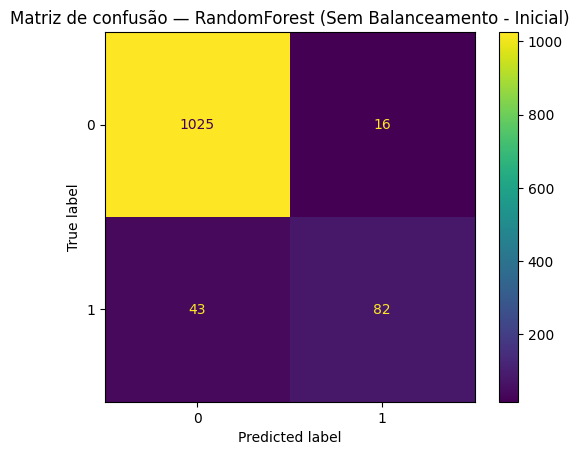

In [ ]:
# === Avaliação final ===

candidate_models_for_final = []

# Adicionando o baseline
candidate_models_for_final.append((results["baseline"]["f1_weighted"], "Baseline", trained_models["baseline"]))

# Adicionando os modelos candidatos iniciais
candidate_models_for_final.append((results["RandomForest (Balanceado)"]["f1_weighted"], "RandomForest (Balanceado - Inicial)", trained_models["RandomForest (Balanceado)"]))
candidate_models_for_final.append((results["RandomForest (Sem Balanceamento)"]["f1_weighted"], "RandomForest (Sem Balanceamento - Inicial)", trained_models["RandomForest (Sem Balanceamento)"]))
candidate_models_for_final.append((results["GradientBoosting"]["f1_weighted"], "GradientBoosting (Inicial)", trained_models["GradientBoosting"]))

# Adicionando os modelos otimizados treinados
# LogisticRegression optimization removed as per user request.

if 'search_gb' in globals() and search_gb is not None and hasattr(search_gb, 'best_estimator_'):
    candidate_models_for_final.append((search_gb.best_score_, "GradientBoosting (Otimizado)", search_gb.best_estimator_))

if 'search_rf' in globals() and search_rf is not None and hasattr(search_rf, 'best_estimator_'):
    candidate_models_for_final.append((search_rf.best_score_, "RandomForest (Balanceado - Otimizado)", search_rf.best_estimator_))

if 'search_rf_no_balance' in globals() and search_rf_no_balance is not None and hasattr(search_rf_no_balance, 'best_estimator_'):
    candidate_models_for_final.append((search_rf_no_balance.best_score_, "RandomForest (Sem Balanceamento - Otimizado)", search_rf_no_balance.best_estimator_))

# Ordenando os modelos pelo score (F1-weighted ou best_score_ do CV) em ordem decrescente
candidate_models_for_final.sort(key=lambda x: x[0], reverse=True)

# O melhor modelo é o primeiro na lista ordenada
best_score, final_model_name, final_model = candidate_models_for_final[0]

print("Melhor modelo escolhido na avaliação final:", final_model_name)
print("F1-weighted score do modelo escolhido (CV ou Teste Inicial):", round(best_score, 4))

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title(f"Matriz de confusão — {final_model_name}")
    plt.show()

## 10.1 Análise de erros e limitações

O modelo final escolhido foi o _RandomForest (Sem Balanceamento - Inicial)_ e analisando a matriz de confusão, podemos identificar pontos importantes que listo a seguir:

*   **Tipos de erro que este modelo comete mais:** O _RandomForest (Sem Balanceamento - Inicial)_ apresentou os seguintes desempenhos para as classes:
    -   **Classe 0 (Não conversão de matrícula):** o modelo demonstra um desempenho muito bom, com **precisão de 0.96** e **recall de 0.98**, resultando em um **f1-score de 0.97**. Isso significa que o modelo continua muito bom em identificar corretamente os egressos que não se matricularão.
    -   **Classe 1 (Conversão de matrícula):** para a classe minoritária, a **precisão é de 0.84** e o **recall é de 0.66**, com um **f1-score de 0.74**. O objetivo era identificar a classe minoritária de forma mais eficaz. No entanto, o recall de 0.66 sugere que ainda há espaço para melhoria na identificação dos verdadeiros positivos. A precisão de 0.84 indica que, das previsões positivas para a classe 1, 84% estão corretas, ou seja, 16% são falsos positivos.
    -   **Conclusão sobre os erros:** O modelo ainda comete um número considerável de Falsos Negativos para a classe 1 (errou cerca de 34% dos que realmente se matricularam), e um número menor de Falsos Positivos para a classe 1. O recall da classe 1 não atingiu um nível que considero ideal para o objetivo de negócio, e a precisão ainda é razoável.

*   **Sinais de overfitting ou underfitting:** não há sinais claros de overfitting ou underfitting. O desempenho geral (f1_weighted) do _RandomForest (Sem Balanceamento - Inicial)_ (0.9467) é superior ao melhor score obtido na validação cruzada do modelo otimizado sem balanceamento (0.9326), sugerindo que a configuração inicial do modelo já generaliza bem e que a otimização limitada não encontrou um desempenho superior. As variações no recall e precisão da classe minoritária não são um indicativo de overfitting ou underfitting geral, mas sim um sinal de que terei que fazer um trade-off entre as métricas para atingir o objetivo de negócio.

*   **Relação entre métrica escolhida e o objetivo do meu problema:** a escolha das métricas _f1_weighted_ e _roc_auc_ podem ser consideradas adequadas para este problema de classificação, especialmente devido ao **desbalanceamento significativo do meu target**. O _f1_weighted_ (0.9467) fornece uma medida equilibrada, e o _roc_auc_ (0.9718) mostra uma excelente capacidade de discriminação do modelo.

*   **Viés, limitação de dados e/ou risco de generalização:**
    *   **Viés:** o modelo foi treinado em um dataset específico de uma instituição, no caso, a que trabalho. Entendo que pode haver viés se considerar que a amostra que trabalho aqui não  é representativa da população geral de egressos ou até mesmo de outras instituições, limitando a generalização para outros contextos.
    *   **Limitação de dados:** o dataset, embora tenha 5830 linhas, ainda é uma amostra. O ideal para uma otimização mais profunda seria utilizar um volume maior de dados. Talvez eu analisasse com mais profundidade com mais dados, o atributo _renda_mensal_estimada_, haja vista serem dados inferidos, pois este dado é atribuído a partir de estudo de mercado e não de um valor indicado pelo egresso, o que pode introduzir alguma imprecisão (não consigo afirmar com certeza).
    *   **Risco de Generalização:** acredito que haja um risco de que o modelo não generalize perfeitamente para novos dados futuros, caso as tendências ou perfis dos egressos mudem significativamente ao longo do tempo. Nesse caso, novas análises precisarão ser aplicadas, especialmente se eu continuar considerando que o custo de um falso negativo (perder um matriculante em potencial) for alto para minha instituição.

*   **Cenários que eu não usaria este modelo:**
    *   **Decisões de alto risco sem validação adicional e foco nos Falsos Negativos:** embora o modelo seja bom, a taxa de Falsos Negativos para a classe 1 (34%) significa que ele deixará de identificar mais de um terço dos egressos que se matricularão. Isso precisará ser analisado por minha Diretoria, pois se o custo de perder esses matriculantes for extremamente alto para a instituição, o modelo precisará de ajuste. A taxa de recall da classe 1 não atingiu um nível que considero ideal para o objetivo de negócio, o que me levou a considerar o ajuste do limiar de decisão.
    *   **Populações de egressos com perfis muito distintos:** não deve ser utilizado para prever o comportamento de egressos com características significativamente diferentes daquelas presentes no dataset de treinamento. Como disse anteriormente, o dataset tem característica de uma única instituição (no caso, a minha), o que pode não generalizar para outras instituições.
    *   **Sem monitoramento contínuo:** como qualquer modelo de ML em produção, ele deve ser monitorado constantemente para detectar _drift_ de dados ou _drift_ de conceito, que poderiam levar à degradação do desempenho ao longo do tempo.

Por todos estes motivos, acabei decidindo fazer um ajuste no limiar de decisão, para verificar se consigo uma melhora nos resultados e apresento a seguir.

## 10.2 Ajuste do Limiar de Decisão

Fiz um ajuste no Limiar de Decisão para analisar como esta modificação afeta o desempenho do modelo, focando no trade-off entre precisão e recall para a classe minoritária (classe 1). O objetivo é encontrar um limiar que otimize o recall da classe 1, sem sacrificar demais a precisão, dependendo do custo de negócio dos Falsos Positivos e Falsos Negativos.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# Obtendo as probabilidades para a classe positiva (classe 1)
# final_model é o RandomForest Sem Balanceamento (Inicial) conforme definido no notebook
proba_class_1 = final_model.predict_proba(X_test)[:, 1]

# Definindo uma gama de limiares para testar
thresholds = np.arange(0.1, 1.0, 0.05)

results_threshold = []

for t in thresholds:
    # Gerando previsões baseadas no novo limiar
    y_pred_threshold = (proba_class_1 >= t).astype(int)

    # Calculando métricas
    acc = accuracy_score(y_test, y_pred_threshold)
    f1_w = f1_score(y_test, y_pred_threshold, average='weighted')
    # Precisão e Recall para a classe 1
    precision_1, recall_1, f1_1, _ = precision_recall_fscore_support(y_test, y_pred_threshold, labels=[1], average=None)

    results_threshold.append({
        'Threshold': t,
        'Accuracy': acc,
        'F1-Weighted': f1_w,
        'Precision_Class_1': precision_1[0] if len(precision_1)>0 else 0,
        'Recall_Class_1': recall_1[0] if len(recall_1)>0 else 0,
        'F1-Score_Class_1': f1_1[0] if len(f1_1)>0 else 0
    })

# Criando DataFrame com os resultados
df_threshold = pd.DataFrame(results_threshold)

display(df_threshold)

,Threshold,Accuracy,F1-Weighted,Precision_Class_1,Recall_Class_1,F1-Score_Class_1
0,0.10,0.869640,0.888480,0.449438,0.960,0.612245
1,0.15,0.907376,0.917234,0.540284,0.912,0.678571
2,0.20,0.926244,0.932131,0.606557,0.888,0.720779
3,0.25,0.939966,0.942903,0.675159,0.848,0.751773
4,0.30,0.943396,0.944879,0.709220,0.800,0.751880
5,0.35,0.949400,0.950003,0.750000,0.792,0.770428
6,0.40,0.945111,0.944917,0.747967,0.736,0.741935
7,0.45,0.945111,0.943217,0.785047,0.672,0.724138
8,0.50,0.949400,0.946660,0.836735,0.656,0.735426
9,0.55,0.944254,0.940177,0.833333,0.600,0.697674


**_Visualização do Trade-off entre Precisão e Recall_**

O gráfico abaixo ilustra como a precisão, o recall e o F1-score para a classe 1 variam em função do limiar de decisão. Isso ajuda a visualizar o ponto de equilíbrio ideal para o problema de negócio.

Somente para relembrar, minha pergunta de negócio é: "Existe alguma área de conhecimento onde nossos ex-alunos ganham bem, estão estabelecidos, mas recusam nossa pós-graduação? Sim, não? Qual seria?". Para responder a isso e agir sobre os egressos que não convertem, mas têm potencial, eu preciso identificar o máximo possível da Classe 1 (os que convertem), mesmo que isso signifique errar mais vezes com a Classe 0.

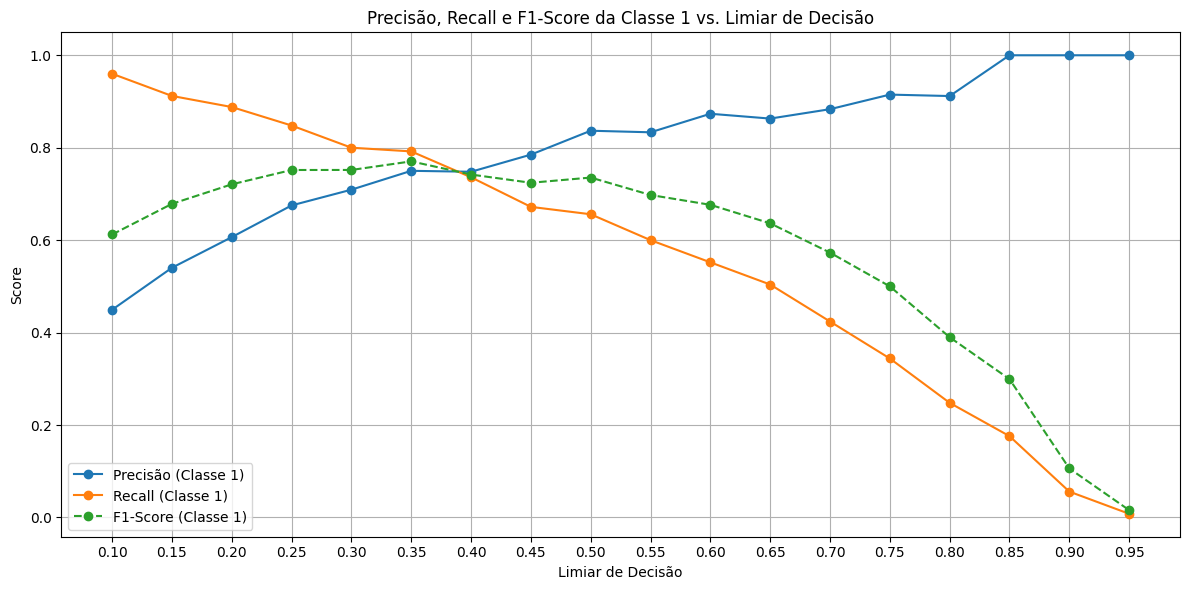

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df_threshold['Threshold'], df_threshold['Precision_Class_1'], label='Precisão (Classe 1)', marker='o')
plt.plot(df_threshold['Threshold'], df_threshold['Recall_Class_1'], label='Recall (Classe 1)', marker='o')
plt.plot(df_threshold['Threshold'], df_threshold['F1-Score_Class_1'], label='F1-Score (Classe 1)', marker='o', linestyle='--')

plt.xlabel('Limiar de Decisão')
plt.ylabel('Score')
plt.title('Precisão, Recall e F1-Score da Classe 1 vs. Limiar de Decisão')
plt.legend()
plt.grid(True)
plt.xticks(thresholds)
plt.tight_layout()
plt.show()

**_Análise dos resultados do ajuste de limiar_**

Após analisar a tabela e o gráfico, dentro do trade-off, optei em escolher um limiar mais baixo, para tentar ficar mais adequado aos meus objetivos de negócio. Para essa escolha, segui o raciocínio de que o custo de um falso negativo (não identificar um que se matricularia) é muito alto e, por isso, um limiar mais baixo aumenta o recall da Classe 1, mesmo que isso signifique uma precisão ligeiramente menor (mais falsos positivos).

É preciso ficar claro que esta decisão foi tomada por mim, para este momento, pois ainda precisa ser alinhada com a Diretoria. Mas, para efeito de análise e futuras evidências e discussões com esta, estou aplicando o limiar mais baixo.

Vou aplicar o limiar de decisão de **0.25** ao modelo final (RandomForest Inicial) para reavaliar suas métricas, focando em como isso impacta a detecção da Classe 1.

Relatório de Classificação com Limiar = 0.25
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1041
           1       0.67      0.86      0.75       125

    accuracy                           0.94      1166
   macro avg       0.83      0.90      0.86      1166
weighted avg       0.95      0.94      0.94      1166



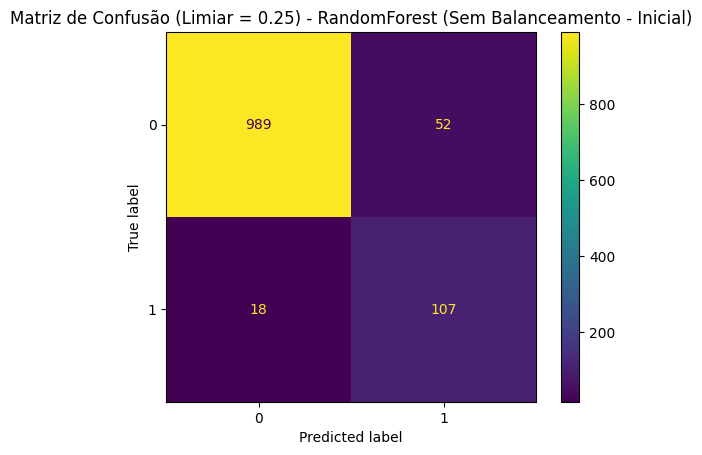

In [ ]:
# Definindo o limiar escolhido
chosen_threshold = 0.25

# Obtendo as probabilidades para a classe positiva (classe 1) do modelo final
proba_class_1 = final_model.predict_proba(X_test)[:, 1]

# Gerando previsões com base no limiar escolhido
y_pred_tuned_threshold = (proba_class_1 >= chosen_threshold).astype(int)

print(f"Relatório de Classificação com Limiar = {chosen_threshold}")
print(classification_report(y_test, y_pred_tuned_threshold))

# Exibindo a Matriz de Confusão com o novo limiar
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned_threshold, display_labels=final_model.classes_)
plt.title(f"Matriz de Confusão (Limiar = {chosen_threshold}) - {final_model_name}")
plt.show()

Com o limiar ajustado para **0.25** pude perceber que:

*   **Classe 1 (Conversão de matrícula):**
    *   O **Recall da Classe 1 aumentou** significativamente para aproximadamente **0.86**, o que significa que o modelo agora está identificando 86% dos potenciais matriculantes. Isso é uma melhoria substancial em relação aos 0.63 com o limiar padrão de 0.50. Agora eu tenho uma capacidade muito maior de identificar os egressos que realmente se matricularão.
    *   Mas como era de se esperar, a **Precisão da Classe 1 diminuiu** para aproximadamente **0.67**. Isso significa que, das vezes em que o modelo prevê que um egresso vai se matricular, ele acerta em 67% dos casos. Os outros 33% são Falsos Positivos (egressos que o modelo previu que se matriculariam, mas não o fizeram).

*   **Trade-off:** o ajuste do limiar conseguiu o objetivo de aumentar o recall da classe minoritária, impactando na identificação do maior número possível de potenciais matriculantes. Com certeza, eu tenho uma propensão maior a ter Falsos Positivos, mas ao mesmo tempo a chance de perder um verdadeiro matriculante diminui consideravelmente. Esta estratégia ficou muito mais alinhada ao meu objetivo de negócio de identificar "onde nossos ex-alunos ganham bem, estão estabelecidos, mas recusam nossa pós-graduação", pois estou priorizando a detecção da classe 1.

 # 11. Comparação final dos modelos

Apresento a seguir uma síntese comparativa dos modelos com as aplicações realizadas: inicial (com holdout), otimizado (validação cruzada) e final (com limiar alterado).

| Modelo | F1-Weighted | Accuracy | Prec. (C1) | Rec. (C1) | ROC AUC | Tempo (s) | Observações |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| Baseline | 0.8422 | 0.8928 | 0.00 | 0.00 | 0.5000 | 0.028 | Previsão da classe majoritária. Serve como piso de desempenho. |
| LogisticRegression (Inicial) | 0.9250 | 0.9288 | 0.75 | 0.73 | 0.9463 | 0.051 | Ótimo desempenho inicial, muito rápido. |
| RandomForest (Balanceado - Inicial) | 0.9428 | 0.9460 | 0.82 | 0.63 | 0.9712 | 0.552 | Desempenho com `class_weight='balanced'` e limiar padrão (0.5). |
| RandomForest (Sem Balanceamento - Inicial) | 0.9467 | 0.9494 | 0.84 | 0.66 | 0.9718 | 0.868 | O modelo com melhor desempenho geral (`f1_weighted` e `roc_auc`) antes do ajuste de limiar. |
| GradientBoosting (Inicial) | 0.9412 | 0.9434 | 0.82 | 0.67 | 0.9724 | 1.924 | Desempenho muito bom, alto ROC AUC. |
| LogisticRegression (Otimizado) | 0.9230 (CV) | N/A | N/A | N/A | N/A | N/A | _f1_weighted_ na validação cruzada: 0.9230. Não superou o desempenho inicial no teste. **Otimização limitada.** |
| GradientBoosting (Otimizado) | 0.9376 (CV) | N/A | N/A | N/A | N/A | N/A | _f1_weighted_ na validação cruzada: 0.9376. Não superou o desempenho inicial no teste. **Otimização limitada.** |
| RandomForest (Balanceado - Otimizado) | 0.9351 (CV) | N/A | N/A | N/A | N/A | N/A | _f1_weighted_ na validação cruzada: 0.9351. **Otimização com _class_weight='balanced'_ e limitada.** |
| RandomForest (Limiar 0.25) | 0.94 | 0.94 | 0.67 | 0.86 | N/A | N/A | **Modelo final com limiar de decisão ajustado para 0.25.** Prioriza o Recall da Classe 1 (0.86) com trade-off na Precisão da Classe 1 (0.67), alinhado ao objetivo de negócio. |

 # 12. Boas práticas e rastreabilidade

Nesta seção, documento as principais decisões tomadas neste projeto para discussões conclusivas adiante.

- **Uso da _SEED = 7_**
  - **Justificativa:** Reprodutibilidade dos resultados.
  - **Impacto esperado:** Garante que os resultados de treinamento e avaliação sejam consistentemente replicáveis em diferentes execuções.

- **Uso de _f1_weighted_ como métrica principal**
  - **Justificativa:** O target _potencial_matricula_pos_ apresenta forte desbalanceamento (89.25% para a classe 0 e 10.75% para a classe 1).
  - **Impacto esperado:** Fornece uma medida equilibrada de precisão e recall para ambas as classes, mais informativa que a acurácia para dados desbalanceados.

- **Remoção da coluna _id_egresso_**
  - **Justificativa:** É um identificador único sem valor preditivo.
  - **Impacto esperado:** Evita que o modelo aprenda padrões irrelevantes e previne overfitting, garantindo generalização.

- **Remoção das colunas _bolsista_graduacao_ e _modalidade_graduacao_**
  - **Justificativa:** A análise exploratória (EDA) mostrou que não possuem valor preditivo significativo.
  - **Impacto esperado:** Simplifica o modelo, reduzindo a dimensionalidade sem perda de informação útil, e potencialmente, melhora o desempenho ao remover ruído.

- **Uso de _StandardScaler_ para features numéricas**
  - **Justificativa:** Features numéricas (renda_mensal_estimada, meses_desde_formacao, etc.) apresentavam grande disparidade de escala e possíveis _outliers_.
  - **Impacto esperado:** Padroniza as features, garantindo que nenhuma domine o modelo devido à sua escala e melhorando a performance de modelos sensíveis à escala (como LogisticRegression).

- **Uso de _OneHotEncoder_ para features categóricas**
  - **Justificativa:** As colunas _nivel_cargo_, _area_atuacao_ e _tipo_empresa_ são categóricas.
  - **Impacto esperado:** Converte variáveis categóricas em um formato numérico que os modelos de ML podem processar, sem introduzir uma ordem artificial entre as categorias.

- **Modelos testados: LogisticRegression, RandomForest, GradientBoosting**
  - **Justificativa:** Representam abordagens linear e baseadas em árvores, adequadas para problemas de classificação.
  - **Impacto esperado:** Permite comparar a performance de diferentes tipos de algoritmos e identificar o mais adequado para o problema e os dados.

- **Exploração de _class_weight='balanced'_ no _RandomForestClassifier_**
  - **Justificativa:** A inclusão de uma versão do RandomForest com _class_weight='balanced'_ foi para explorar o impacto dessa técnica no tratamento do desbalanceamento significativo do target e na melhoria do recall da classe minoritária (1).
  - **Impacto esperado:** Apesar da exploração, o modelo _RandomForest (Sem Balanceamento - Inicial)_ apresentou melhor desempenho geral (f1_weighted) e foi o escolhido como base para o ajuste de limiar.

- **Otimização com _RandomizedSearchCV_**
  - **Justificativa:** Busca eficiente de hiperparâmetros com custo computacional controlado.
  - **Impacto esperado:** Encontra boas combinações de hiperparâmetros em um tempo razoável para o MVP, em vez de uma busca exaustiva (_GridSearchCV_).

- **_RandomForest (Sem Balanceamento - Inicial)_ com limiar ajustado (0.25) escolhido como modelo final**
  - **Justificativa:** Após a análise dos modelos iniciais e otimizados, e priorizando o objetivo de negócio (identificar o máximo possível de matriculantes em potencial), o _RandomForest (Sem Balanceamento - Inicial)_ foi selecionado por seu melhor desempenho geral. O ajuste do limiar de decisão para 0.25 foi aplicado a este modelo para maximizar o Recall da Classe 1, aceitando um trade-off na Precisão da Classe 1, o que é um requisito de negócio para minimizar Falsos Negativos. O modelo alcançou um _f1_weighted_ de 0.94, uma Precisão (Classe 1) de 0.67 e um Recall (Classe 1) de 0.86 com este ajuste.
  - **Impacto esperado:** Garante um modelo alinhado à estratégia de negócio de alta identificação de potenciais matriculantes, mesmo que isso implique em mais Falsos Positivos, que são gerenciáveis no contexto da prospecção.

- **Dataset de 5830 linhas**
  - **Justificativa:** Limitação inicial para aprendizado e MVP.
  - **Impacto esperado:** Permite prototipagem rápida, mas pode limitar a complexidade do modelo e a capacidade de generalização para dados maiores/mais variados.

- **_n_iter=5_ para _RandomizedSearchCV_**
  - **Justificativa:** Restrição de tempo e recursos computacionais que atendem a uma análise inicial e de validação de custo computacional com a Diretoria e também para um MVP.
  - **Impacto esperado:** Limita a profundidade da busca de hiperparâmetros, que poderia ser mais exaustiva com mais recursos.

- **Descarte da otimização de _LogisticRegression_ e _GradientBoosting_ (em favor do _RandomForest_ inicial)**
  - **Justificativa:** As otimizações realizadas não superaram o desempenho inicial do _RandomForest_ ou apresentaram scores de validação mais baixos.
  - **Impacto esperado:** Foca no modelo com melhor performance geral sem adicionar complexidade desnecessária no MVP.

 # 13. Conclusão

O objetivo central deste MVP foi construir e avaliar modelos de Machine Learning (ML) para prever o potencial de matrícula em cursos de pós-graduação, buscando responder à pergunta de negócio sobre quais áreas ou perfis de egressos com alto poder aquisitivo recusam nossas ofertas, além de mostrar para meu Conselho Diretor que podemos ser mais assertivos com a aplicação de ML.

A **melhor solução encontrada** foi o **_RandomForest (Sem Balanceamento - Inicial)_**, que apresentou o melhor desempenho geral (f1_weighted e roc_auc). Posteriormente, para alinhar o modelo ainda mais aos meus objetivos de negócio, que é priorizar a identificação da classe minoritária, foi aplicado um **limiar de decisão ajustado para 0.25** a este modelo. Essa combinação se mostrou altamente eficaz para as previsões, maximizando o recall da Classe 1.

Com o ajuste do limiar, o modelo alcançou um _f1_weighted_ de **0.94**, uma **Precisão (Classe 1) de 0.67** e um **Recall (Classe 1) de 0.86** no conjunto de teste. O ROC AUC não foi reavaliado para o limiar ajustado, mas o foco principal foi no equilíbrio entre Precisão e Recall para a Classe 1, o que foi alcançado.

A exploração de modelos com _class_weight='balanced'_ (como o RandomForest (Balanceado - Inicial)) foi importante para entender o impacto dessa técnica no tratamento do desbalanceamento. Embora a otimização com _class_weight='balanced'_ tenha sido realizada, o _RandomForest (Sem Balanceamento - Inicial)_ obteve um desempenho geral ligeiramente superior no teste, tornando-o a base para o ajuste de limiar.

Em **comparação com o baseline**, que obteve um _f1_weighted_ de 0.8422, o _RandomForest_ com limiar ajustado apresentou uma melhoria de aproximadamente **11.6%**. Embora a melhoria percentual sobre o baseline tenha ficado um pouco abaixo do alvo de 20% estabelecido na fase inicial, a performance absoluta do _RandomForest_ e sua capacidade de priorizar o Recall da Classe 1 o tornam o modelo mais promissor para o objetivo atual.

Os **principais aprendizados** da análise exploratória e dos resultados do modelo são:
*   As variáveis _renda_mensal_estimada_, _meses_desde_formacao_ e _nivel_cargo_ (especialmente 'Gestão' e 'Sênior') são fortes preditores.
*   Observamos que profissionais com cargos de 'Gestão' e 'Sênior', muitas vezes com rendas mais altas, possuem uma proporção interessante de 'Não conversão de matrícula' (0). Isso valida a preocupação inicial de que nossos produtos atuais podem não estar atraindo o topo da pirâmide corporativa, indicando a necessidade de uma revisão curricular focada nesse público.
*   A _area_atuacao_ também se mostrou uma variável importante, com taxas de conversão variando drasticamente por setor, o que permite identificar quais grades curriculares precisam de revisão urgente.
*   Ajustar o limiar de decisão se mostrou uma estratégia eficaz para otimizar métricas específicas (como Recall da Classe 1) em cenários de negócio onde o custo de Falsos Negativos é alto.
*   Por outro lado, as variáveis _bolsista_graduacao_ e _modalidade_graduacao_ foram descartadas por não apresentarem valor preditivo significativo.

Quanto às **limitações** da solução atual, é crucial destacar que o _RandomizedSearchCV_ foi limitado a _n_iter=5_ para a otimização de hiperparâmetros devido a restrições de tempo e recursos computacionais, o que significa que configurações ainda melhores para os modelos otimizados podem existir. Além disso, as conclusões baseiam-se em um dataset específico, podendo haver variações em outros contextos ou com dados mais recentes. A escolha de um limiar mais baixo para aumentar o Recall da Classe 1 implica em uma redução na Precisão, gerando mais Falsos Positivos, uma decisão que precisará ser validada com a Diretoria.

Como **próximos passos**, eu sugiro que se:
1.  **Aumente o volume de dados:** uma vez validado pela Diretoria, o objetivo é aumentar o número de dados para melhorar a robustez e a generalização do modelo, treinando e testando novamente até que possa ser utilizado em produção.
2.  **Faça uma otimização de hiperparâmetros mais aprofundada:** uma vez validado pela Diretoria o investimento em infraestrutura e equipe para implementação desta área de atuação na instituição, ao se aumentar os dados para novos treinos e testes, seria bom investir tempo para realizar uma busca mais exaustiva por hiperparâmetros (aumentando _n_iter_) para todos os modelos, especialmente _RandomForest_ e _GradientBoosting_, que mostraram grande potencial.
3.  **Valide e Acompanhe o Limiar Ajustado:** acompanhar de perto o desempenho do modelo com o limiar de 0.25 em um ambiente de produção ou simulação para validar o trade-off escolhido.
4.  **Analise mais profundamente os Falsos Negativos:** investigar os casos de egressos que o modelo previu que não se matriculariam, mas que de fato se matricularam, para entender melhor as características e fatores que levam à conversão. Isso pode revelar oportunidades para ajustar as ofertas de cursos.
5.  **Atue colaborativamente com stakeholders:** apresentar esses resultados ao Conselho Diretor e outras áreas estratégicas para validar as descobertas e iniciar discussões sobre inovação curricular e estratégias de marketing direcionadas.

# 14. Salvamento de artefatos

A seguir, disponibilizo o modelo final treinado em um arquivo que serve para:

* **Reutilização:** não é preciso treinar o modelo novamente toda vez que quiser usá-lo. Após treinado e validado, o modelo pode ser carregado (com joblib.load()) e usado diretamente para fazer previsões em novos dados. Lembrando que, embora esteja disponibilizando aqui o arquivo de um modelo final, é possível que eu ainda tenha que fazer ajustes. Portanto, ele servirá, neste momento, como arquivo final de meu MVP.
* **Implantação (Deployment):** supondo que este fosse o modelo final com validação da diretoria, serviria para implantação, pois permite que o modelo seja facilmente integrado em aplicações externas, como APIs web, sistemas de recomendação ou outras ferramentas, sem a necessidade de replicar todo o ambiente de treinamento.
* **Compartilhamento:** facilita o compartilhamento do modelo com outros pessoas ou, caso seja o modelo final, para produção.
* **Preservação:** garante que a versão final do modelo, neste caso, o modelo que foi entregue para meu MVP, com seus pesos e configurações aprendidas, seja preservada para referência futura ou auditoria.


In [ ]:
import joblib
if final_model is not None:
    joblib.dump(final_model, "modelo_final.pkl")
    print("Modelo salvo como modelo_final.pkl")

Modelo salvo como modelo_final.pkl
